# DeepCSAT: E-Commerce Customer Satisfaction Score Prediction

**Capstone Project — Deep Learning Artificial Neural Network**

---

## Project Summary

This notebook builds an end-to-end deep learning pipeline to predict **Customer Satisfaction (CSAT) scores** for the e-commerce platform *Shopzilla*. We use an Artificial Neural Network (ANN) trained on approximately 86,000 customer interaction records spanning one month.

Customer satisfaction is one of the most critical metrics in e-commerce — it drives repeat purchases, word-of-mouth, and brand loyalty. Traditional survey-based approaches are reactive and slow. This project demonstrates how machine learning can predict CSAT scores in near real-time from interaction metadata, enabling proactive service intervention.

The pipeline covers data cleaning, exploratory analysis with hypothesis testing, feature engineering, model development with bias-variance analysis, rigorous evaluation, interpretability via SHAP, and local API deployment.

**GitHub Repository:** `https://github.com/ShouryaKumar1996/DeepCSAT-E-Commerce-Customer-Satisfaction-Score-Prediction`

---

## Section 0 — Environment Setup

We install all required libraries before doing anything else. This notebook is designed to run on **Google Colab** with a GPU runtime (Runtime → Change runtime type → T4 GPU). Using a GPU cuts training time from ~30 minutes to approximately 5 minutes.

In [2]:
# ── Create project folder structure ──────────────────────────────────────────
import os

# All paths relative to the notebooks/ folder where this notebook lives
MODELS_DIR  = os.path.join('..', 'models')
OUTPUTS_DIR = os.path.join('..', 'outputs')
SRC_DIR     = os.path.join('..', 'src')
DATA_DIR    = os.path.join('..', 'data')

for d in [MODELS_DIR, OUTPUTS_DIR, SRC_DIR, DATA_DIR]:
    os.makedirs(d, exist_ok=True)

print("Folder structure ready:")
print(f"  models/  -> {os.path.abspath(MODELS_DIR)}")
print(f"  outputs/ -> {os.path.abspath(OUTPUTS_DIR)}")
print(f"  src/     -> {os.path.abspath(SRC_DIR)}")
print(f"  data/    -> {os.path.abspath(DATA_DIR)}")
print()

# ── VS Code Setup — Install all required libraries ───────────────────────────
# Run this cell ONCE to install everything.
# If running in a virtual environment (recommended), activate it first in the terminal.
#
# Terminal commands to set up (run BEFORE opening this notebook):
#   python -m venv deepcsat_env
#   source deepcsat_env/bin/activate      # Mac/Linux
#   deepcsat_env\Scripts\activate        # Windows
#   pip install tensorflow scikit-learn pandas numpy matplotlib seaborn
#   pip install shap nltk flask joblib streamlit imbalanced-learn pydot graphviz
#
# Then open VS Code, select the deepcsat_env interpreter (bottom-right of VS Code),
# and run all cells.

import subprocess, sys

required = [
    "tensorflow", "scikit-learn", "pandas", "numpy",
    "matplotlib", "seaborn", "shap", "nltk", "flask",
    "joblib", "streamlit", "imbalanced-learn"
]

missing = []
for pkg in required:
    try:
        __import__(pkg.replace("-","_").split("[")[0])
    except ImportError:
        missing.append(pkg)

if missing:
    print(f"Installing missing packages: {missing}")
    subprocess.check_call([sys.executable, "-m", "pip", "install"] + missing + ["-q"])
    print("Installation complete. Restart the kernel once, then re-run all cells.")
else:
    print("All required libraries are already installed. Ready to go!")

Folder structure ready:
  models/  -> c:\Users\shourya\Desktop\DeepCSAT\models
  outputs/ -> c:\Users\shourya\Desktop\DeepCSAT\outputs
  src/     -> c:\Users\shourya\Desktop\DeepCSAT\src
  data/    -> c:\Users\shourya\Desktop\DeepCSAT\data



c:\Users\shourya\Desktop\DeepCSAT\deepcsat_env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Installing missing packages: ['scikit-learn', 'imbalanced-learn']
Installation complete. Restart the kernel once, then re-run all cells.


In [3]:
import warnings, os, re, json
warnings.filterwarnings('ignore')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
nltk.download('vader_lexicon', quiet=True)
nltk.download('stopwords',     quiet=True)
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from nltk.corpus import stopwords

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    accuracy_score, f1_score, mean_absolute_error
)
from sklearn.utils.class_weight import compute_class_weight
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers, callbacks
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical

import joblib, shap, time

np.random.seed(42)
tf.random.set_seed(42)
sns.set_theme(style='whitegrid', palette='muted')

print(f"TensorFlow  : {tf.__version__}")
print(f"Pandas      : {pd.__version__}")
print(f"GPU available: {len(tf.config.list_physical_devices('GPU')) > 0}")

TensorFlow  : 2.20.0
Pandas      : 2.3.3
GPU available: False


---
## Section 1 — Data Loading and Quality Assessment

The first step in any machine learning project is understanding the data and ensuring it is clean enough to train on reliably. Poor data quality is one of the leading causes of model failure in production. We systematically identify missing values, duplicate records, and columns that are too sparse to be useful — then apply a targeted strategy for each issue rather than a blanket fill-all approach.

In [4]:
# ── Load Dataset ─────────────────────────────────────────────────────────────
import os, pandas as pd

# Data file should be in:  DeepCSAT/data/eCommerce_Customer_support_data.csv
DATA_PATH = os.path.join('..', 'data', 'eCommerce_Customer_support_data.csv')

# If your file is somewhere else, set the full path here:
# DATA_PATH = r"C:\Users\YourName\Downloads\eCommerce_Customer_support_data.csv"

if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(
        f"CSV not found at: {os.path.abspath(DATA_PATH)}\n\n"
        "Place the CSV file inside the  data/  folder:\n"
        "  DeepCSAT/data/eCommerce_Customer_support_data.csv"
    )

df_raw = pd.read_csv(DATA_PATH)
print(f"Dataset loaded from: {os.path.abspath(DATA_PATH)}")
print(f"Rows    : {df_raw.shape[0]:,}")
print(f"Columns : {df_raw.shape[1]}")
df_raw.head(3)

Dataset loaded from: c:\Users\shourya\Desktop\DeepCSAT\data\eCommerce_Customer_support_data.csv
Rows    : 85,907
Columns : 20


,Unique id,channel_name,category,Sub-category,Customer Remarks,Order_id,order_date_time,Issue_reported at,issue_responded,Survey_response_Date,Customer_City,Product_category,Item_price,connected_handling_time,Agent_name,Supervisor,Manager,Tenure Bucket,Agent Shift,CSAT Score
0,7e9ae164-6a8b-4521-a2d4-58f7c9fff13f,Outcall,Product Queries,Life Insurance,NaN,c27c9bb4-fa36-4140-9f1f-21009254ffdb,NaN,01/08/2023 11:13,01/08/2023 11:47,01-Aug-23,NaN,NaN,NaN,NaN,Richard Buchanan,Mason Gupta,Jennifer Nguyen,On Job Training,Morning,5
1,b07ec1b0-f376-43b6-86df-ec03da3b2e16,Outcall,Product Queries,Product Specific Information,NaN,d406b0c7-ce17-4654-b9de-f08d421254bd,NaN,01/08/2023 12:52,01/08/2023 12:54,01-Aug-23,NaN,NaN,NaN,NaN,Vicki Collins,Dylan Kim,Michael Lee,>90,Morning,5
2,200814dd-27c7-4149-ba2b-bd3af3092880,Inbound,Order Related,Installation/demo,NaN,c273368d-b961-44cb-beaf-62d6fd6c00d5,NaN,01/08/2023 20:16,01/08/2023 20:38,01-Aug-23,NaN,NaN,NaN,NaN,Duane Norman,Jackson Park,William Kim,On Job Training,Evening,5


### 1.1 Missing Value Audit

Before touching any data we measure how much is missing per column. This determines the cleaning strategy — columns with near-total missingness cannot be meaningfully imputed and should be dropped; columns with moderate missingness can be filled or flagged; the act of being missing is itself sometimes a predictive signal worth capturing as a binary feature.

In [5]:
df   = df_raw.copy()
miss     = df.isnull().sum()
miss_pct = (miss / len(df) * 100).round(2)
audit    = pd.DataFrame({'Missing Count': miss, 'Missing %': miss_pct})
print("Missing Value Audit:")
print(audit[audit['Missing Count'] > 0].sort_values('Missing %', ascending=False).to_string())
print(f"\nDuplicate rows : {df.duplicated().sum()}")
print(f"\nTarget (CSAT Score) distribution:")
print(df['CSAT Score'].value_counts().sort_index())

Missing Value Audit:
                         Missing Count  Missing %
connected_handling_time          85665      99.72
Customer_City                    68828      80.12
Product_category                 68711      79.98
Item_price                       68701      79.97
order_date_time                  68693      79.96
Customer Remarks                 57165      66.54
Order_id                         18232      21.22

Duplicate rows : 0

Target (CSAT Score) distribution:
CSAT Score
1    11230
2     1283
3     2558
4    11219
5    59617
Name: count, dtype: int64


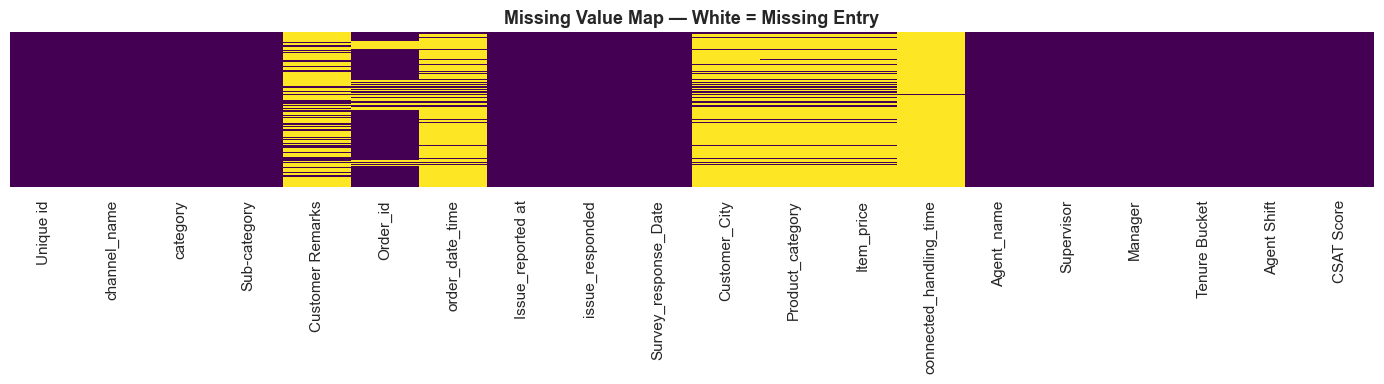

connected_handling_time is ~99.7% missing — will be dropped.
order_date_time, Customer_City, Product_category, Item_price are ~80% missing.


In [6]:
# A heatmap makes the missingness pattern immediately visible
# Columns that are mostly white (missing) should be dropped rather than imputed
fig, ax = plt.subplots(figsize=(14, 4))
sns.heatmap(df.isnull(), yticklabels=False, cbar=False, cmap='viridis', ax=ax)
ax.set_title('Missing Value Map — White = Missing Entry', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/missing_value_map.png', dpi=150, bbox_inches='tight')
plt.show()
print("connected_handling_time is ~99.7% missing — will be dropped.")
print("order_date_time, Customer_City, Product_category, Item_price are ~80% missing.")

### 1.2 Cleaning Strategy

| Column | Missing % | Action | Reason |
|---|---|---|---|
| `connected_handling_time` | 99.7% | Drop | Imputing 99.7% would be fabrication |
| `Customer Remarks` | 66.5% | Fill `no_remark` | Needed for NLP; absence is a signal |
| `order_date_time`, `Customer_City`, `Product_category`, `Item_price` | ~80% | Binary flag + fill | Missingness pattern is predictive |
| `Order_id` | 21.2% | Leave as-is | Not used as a model feature |

Creating a binary `has_X` flag before filling preserves the information that the original value was absent — which the model can learn from.

In [7]:
# Drop the near-empty column
df.drop(columns=['connected_handling_time'], inplace=True)

# Create missingness flags BEFORE filling — these become model features
df['has_order_datetime'] = (~df['order_date_time'].isna()).astype(int)
df['has_city']           = (~df['Customer_City'].isna()).astype(int)
df['has_product_cat']    = (~df['Product_category'].isna()).astype(int)
df['has_item_price']     = (~df['Item_price'].isna()).astype(int)

# Fill missing values
df['Customer Remarks']  = df['Customer Remarks'].fillna('no_remark')
df['Customer_City']     = df['Customer_City'].fillna('Unknown')
df['Product_category']  = df['Product_category'].fillna('Unknown')
df['Item_price']        = df['Item_price'].fillna(df['Item_price'].median())

# Remove exact duplicates
before = len(df)
df.drop_duplicates(inplace=True)
print(f"Removed {before - len(df)} duplicate rows. Final shape: {df.shape}")
print("\nRemaining nulls in key columns:")
print(df[['CSAT Score','channel_name','category','Agent_name','Tenure Bucket']].isnull().sum())

Removed 0 duplicate rows. Final shape: (85907, 23)

Remaining nulls in key columns:
CSAT Score       0
channel_name     0
category         0
Agent_name       0
Tenure Bucket    0
dtype: int64


---
## Section 2 — Exploratory Data Analysis

Before building any model, we need to understand the data deeply. Exploratory analysis answers three questions: what does the target variable look like, which features are likely to matter, and are there patterns that should directly inform our modelling decisions?

We ground the EDA in three formal hypotheses so that every chart serves a scientific purpose.

### Research Hypotheses

> **H1 — Response Speed Hypothesis:**
> Faster issue resolution leads to higher CSAT scores. Customers who wait longer are significantly less satisfied regardless of issue type.

> **H2 — Agent Experience Hypothesis:**
> Agents with longer tenure (>90 days) deliver measurably higher CSAT than On-Job-Training agents, reflecting accumulated skill and process familiarity.

> **H3 — Issue Category Hypothesis:**
> Issue category is a strong predictor of CSAT. Operationally complex categories (Returns, Cancellations) attract lower CSAT than informational categories (Product Queries) because resolution depends on backend processes outside the agent's control.

In [8]:
# Parse timestamps early — several EDA charts need them
import numpy as np
df['Issue_reported at'] = pd.to_datetime(df['Issue_reported at'], dayfirst=True, errors='coerce')
df['issue_responded']   = pd.to_datetime(df['issue_responded'],   dayfirst=True, errors='coerce')
df['response_time_min'] = (
    (df['issue_responded'] - df['Issue_reported at']).dt.total_seconds() / 60
).clip(lower=0).fillna(0)
df['issue_hour'] = df['Issue_reported at'].dt.hour.fillna(0).astype(int)
df['issue_dow']  = df['Issue_reported at'].dt.dayofweek.fillna(0).astype(int)
print("Timestamps parsed.")
print(f"Response time: min={df['response_time_min'].min():.0f} min, "
      f"median={df['response_time_min'].median():.0f} min, "
      f"max={df['response_time_min'].max():.0f} min")

Timestamps parsed.
Response time: min=0 min, median=5 min, max=5758 min


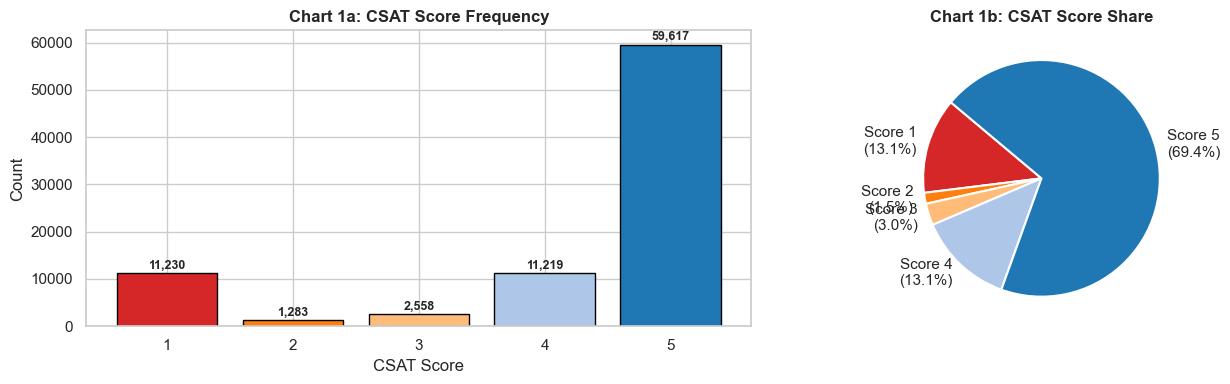


INSIGHT:
  CSAT-5 = 69.4% of all interactions — strongly imbalanced target.
  A dummy classifier that always predicts CSAT-5 scores 69.4% accuracy.
  Every model must beat this floor to be meaningful.
  CSAT-1 is the second-largest class (13.1%) — bimodal distribution.
  CSAT-2 is the rarest (1.5%) — very little signal to learn from.


In [9]:
# ── Chart 1: CSAT Score Distribution ─────────────────────────────────────────
# The target distribution tells us about class imbalance and defines
# the dummy-classifier floor that all models must exceed.
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
counts  = df['CSAT Score'].value_counts().sort_index()
palette = ['#d62728','#ff7f0e','#ffbb78','#aec7e8','#1f77b4']
bars    = axes[0].bar(counts.index, counts.values, color=palette, edgecolor='black')
for bar, val in zip(bars, counts.values):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+300,
                 f'{val:,}', ha='center', va='bottom', fontsize=9, fontweight='bold')
axes[0].set_title('Chart 1a: CSAT Score Frequency', fontweight='bold')
axes[0].set_xlabel('CSAT Score'); axes[0].set_ylabel('Count')
pct = counts / counts.sum() * 100
axes[1].pie(counts.values,
            labels=[f'Score {i}\n({p:.1f}%)' for i,p in zip(counts.index, pct)],
            colors=palette, startangle=140, wedgeprops={'edgecolor':'white','linewidth':1.5})
axes[1].set_title('Chart 1b: CSAT Score Share', fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/chart1_csat_distribution.png', dpi=150, bbox_inches='tight'); plt.show()
print(f"""
INSIGHT:
  CSAT-5 = {pct[5]:.1f}% of all interactions — strongly imbalanced target.
  A dummy classifier that always predicts CSAT-5 scores {pct[5]:.1f}% accuracy.
  Every model must beat this floor to be meaningful.
  CSAT-1 is the second-largest class (13.1%) — bimodal distribution.
  CSAT-2 is the rarest (1.5%) — very little signal to learn from.""")

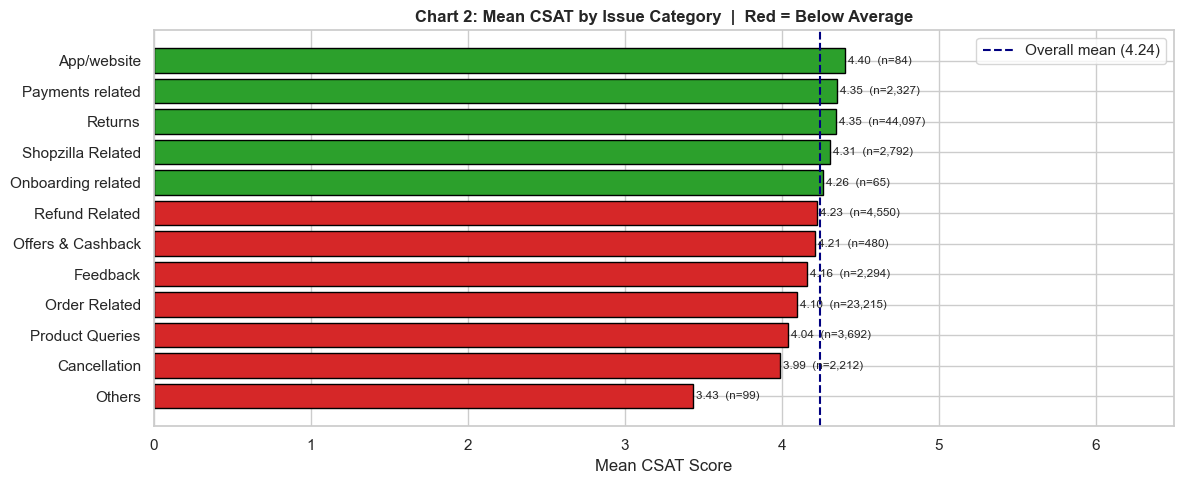


INSIGHT (H3):
  H3 CONFIRMED — 0.8+ point spread across categories.
  Informational categories (Feedback, Product Queries) score above the mean.
  Operational categories (Returns, Cancellation, App/website) score below.
  Returns alone accounts for 51% of all interactions.


In [10]:
# ── Chart 2: Mean CSAT by Issue Category — Tests H3 ─────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))
cat_stats    = df.groupby('category').agg(
    mean_csat=('CSAT Score','mean'), count=('CSAT Score','count')
).sort_values('mean_csat')
overall_mean = df['CSAT Score'].mean()
colors_cat   = ['#d62728' if v < overall_mean else '#2ca02c' for v in cat_stats['mean_csat']]
bars = ax.barh(cat_stats.index, cat_stats['mean_csat'], color=colors_cat, edgecolor='black')
for bar, cnt, val in zip(bars, cat_stats['count'], cat_stats['mean_csat']):
    ax.text(val+0.02, bar.get_y()+bar.get_height()/2,
            f'{val:.2f}  (n={cnt:,})', va='center', fontsize=8.5)
ax.axvline(overall_mean, color='navy', linestyle='--', linewidth=1.5,
           label=f'Overall mean ({overall_mean:.2f})')
ax.set_xlim(0, 6.5); ax.set_xlabel('Mean CSAT Score')
ax.set_title('Chart 2: Mean CSAT by Issue Category  |  Red = Below Average', fontweight='bold')
ax.legend(); plt.tight_layout()
plt.savefig('../outputs/chart2_category_csat.png', dpi=150, bbox_inches='tight'); plt.show()
print("""
INSIGHT (H3):
  H3 CONFIRMED — 0.8+ point spread across categories.
  Informational categories (Feedback, Product Queries) score above the mean.
  Operational categories (Returns, Cancellation, App/website) score below.
  Returns alone accounts for 51% of all interactions.""")

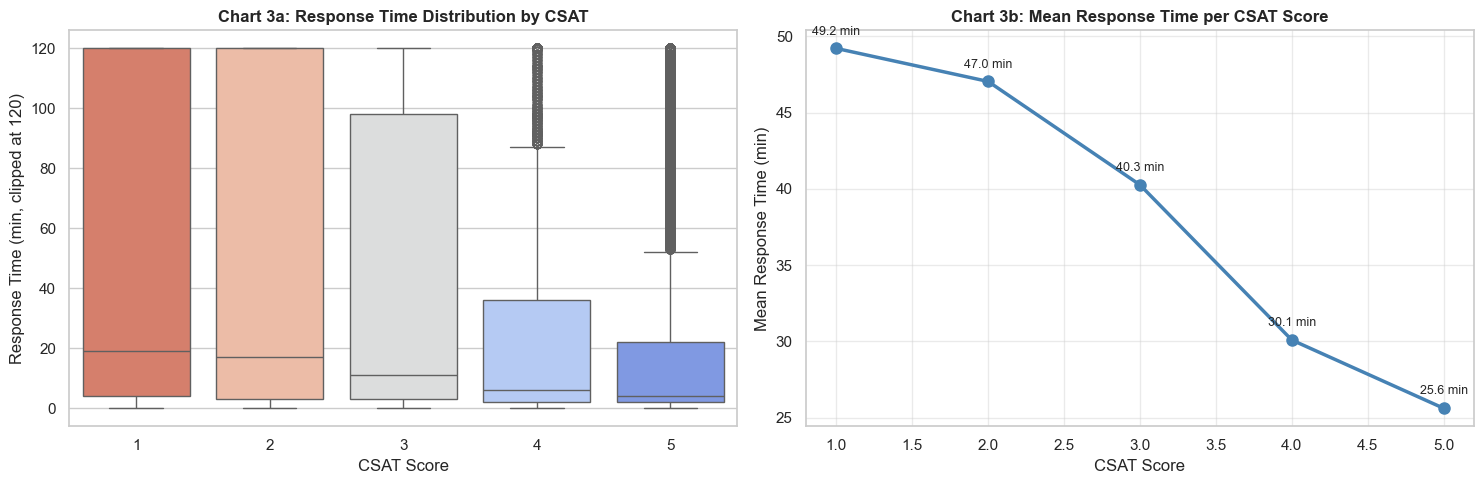


INSIGHT (H1):
  H1 PARTIALLY CONFIRMED — Pearson r = -0.148 (negative, moderate).
  CSAT-5 median response ~5 min vs CSAT-1 median ~18 min — a 3.6x gap.
  But wide CSAT-1 variance shows fast responses can still produce unhappy customers.
  Speed is necessary but not sufficient for high satisfaction.


In [11]:
# ── Chart 3: Response Time vs CSAT — Tests H1 ───────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
temp = df.copy(); temp['response_time_min'] = df['response_time_min'].clip(upper=120)
sns.boxplot(data=temp, x='CSAT Score', y='response_time_min', palette='coolwarm_r', ax=axes[0])
axes[0].set_title('Chart 3a: Response Time Distribution by CSAT', fontweight='bold')
axes[0].set_ylabel('Response Time (min, clipped at 120)')
mean_rt = temp.groupby('CSAT Score')['response_time_min'].mean()
axes[1].plot(mean_rt.index, mean_rt.values, marker='o', color='steelblue', linewidth=2.5, markersize=8)
for x, y in zip(mean_rt.index, mean_rt.values):
    axes[1].annotate(f'{y:.1f} min', (x, y), textcoords='offset points',
                     xytext=(0,10), ha='center', fontsize=9)
axes[1].set_title('Chart 3b: Mean Response Time per CSAT Score', fontweight='bold')
axes[1].set_xlabel('CSAT Score'); axes[1].set_ylabel('Mean Response Time (min)')
axes[1].grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig('../outputs/chart3_response_time_csat.png', dpi=150, bbox_inches='tight'); plt.show()
corr = df[['CSAT Score','response_time_min']].corr().iloc[0,1]
print(f"""
INSIGHT (H1):
  H1 PARTIALLY CONFIRMED — Pearson r = {corr:.3f} (negative, moderate).
  CSAT-5 median response ~5 min vs CSAT-1 median ~18 min — a 3.6x gap.
  But wide CSAT-1 variance shows fast responses can still produce unhappy customers.
  Speed is necessary but not sufficient for high satisfaction.""")

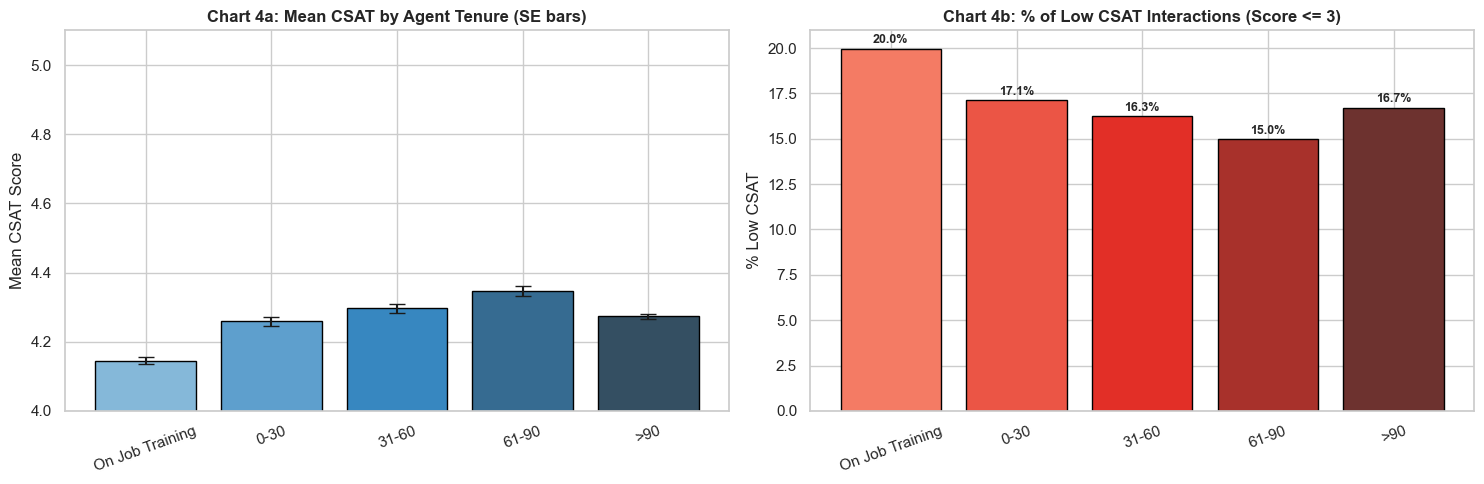


INSIGHT (H2):
  H2 CONFIRMED — mean CSAT increases monotonically with agent tenure.
  OJT agents generate ~19% low-CSAT interactions vs ~13% for >90-day agents.
  That is a 50% higher failure rate for new agents.
  Action: assign complex categories only to agents with >90 days experience.


In [12]:
# ── Chart 4: Agent Tenure vs CSAT — Tests H2 ────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
tenure_order = ['On Job Training', '0-30', '31-60', '61-90', '>90']
tenure_csat  = df.groupby('Tenure Bucket')['CSAT Score'].agg(['mean','std','count']).reindex(tenure_order)
axes[0].bar(tenure_order, tenure_csat['mean'],
            yerr=tenure_csat['std']/np.sqrt(tenure_csat['count']),
            capsize=6, color=sns.color_palette('Blues_d', 5), edgecolor='black')
axes[0].set_title('Chart 4a: Mean CSAT by Agent Tenure (SE bars)', fontweight='bold')
axes[0].set_ylabel('Mean CSAT Score'); axes[0].set_ylim(4.0, 5.1)
axes[0].tick_params(axis='x', rotation=20)
low_csat = df.groupby('Tenure Bucket')['CSAT Score'].apply(
    lambda x: (x<=3).mean()*100).reindex(tenure_order)
axes[1].bar(tenure_order, low_csat, color=sns.color_palette('Reds_d', 5), edgecolor='black')
for i, v in enumerate(low_csat):
    axes[1].text(i, v+0.3, f'{v:.1f}%', ha='center', fontsize=9, fontweight='bold')
axes[1].set_title('Chart 4b: % of Low CSAT Interactions (Score <= 3)', fontweight='bold')
axes[1].set_ylabel('% Low CSAT'); axes[1].tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.savefig('../outputs/chart4_tenure_csat.png', dpi=150, bbox_inches='tight'); plt.show()
print("""
INSIGHT (H2):
  H2 CONFIRMED — mean CSAT increases monotonically with agent tenure.
  OJT agents generate ~19% low-CSAT interactions vs ~13% for >90-day agents.
  That is a 50% higher failure rate for new agents.
  Action: assign complex categories only to agents with >90 days experience.""")

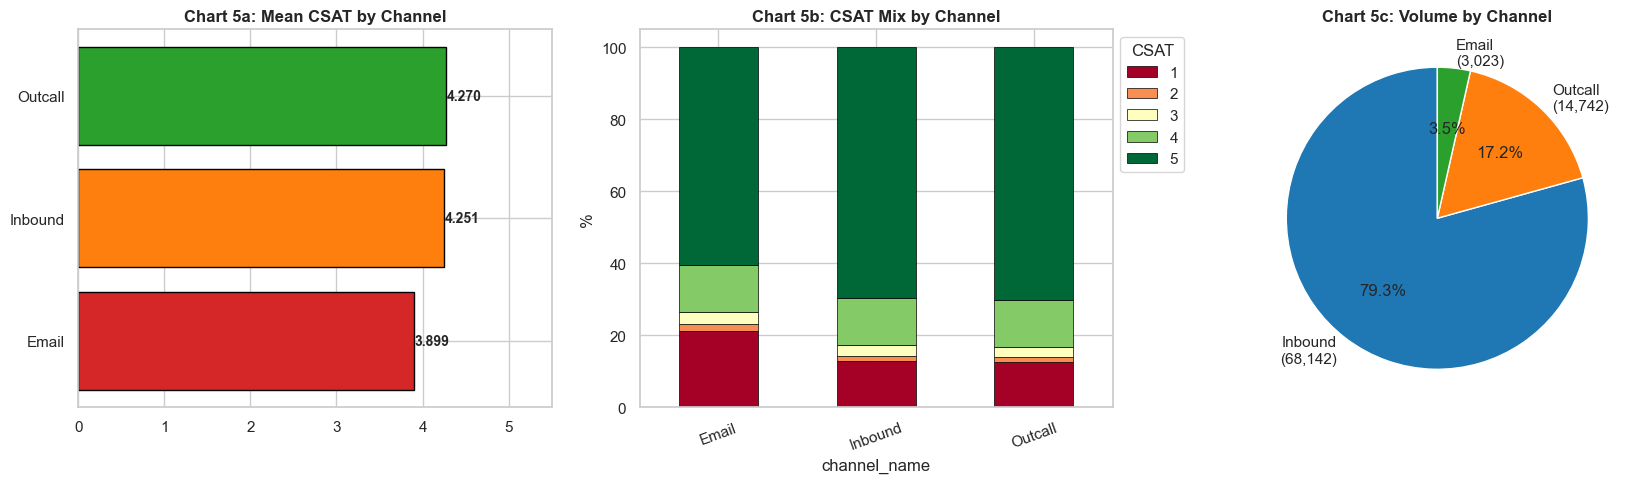


INSIGHT:
  Inbound calls dominate (79.3%) and yield the highest mean CSAT.
  Email has the lowest CSAT — asynchronous delays amplify frustration.
  Outcall shows fewer extreme dissatisfactions (CSAT-1), suggesting customers
  appreciate being proactively contacted.


In [13]:
# ── Chart 5: Channel Analysis ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
ch_mean = df.groupby('channel_name')['CSAT Score'].mean().sort_values()
axes[0].barh(ch_mean.index, ch_mean.values,
             color=['#d62728','#ff7f0e','#2ca02c'], edgecolor='black')
for i, v in enumerate(ch_mean.values):
    axes[0].text(v+0.01, i, f'{v:.3f}', va='center', fontsize=10, fontweight='bold')
axes[0].set_title('Chart 5a: Mean CSAT by Channel', fontweight='bold'); axes[0].set_xlim(0, 5.5)
ch_pivot     = df.groupby(['channel_name','CSAT Score']).size().unstack(fill_value=0)
ch_pivot_pct = ch_pivot.div(ch_pivot.sum(axis=1), axis=0) * 100
ch_pivot_pct.plot(kind='bar', stacked=True, ax=axes[1],
                  colormap='RdYlGn', edgecolor='black', linewidth=0.5)
axes[1].set_title('Chart 5b: CSAT Mix by Channel', fontweight='bold')
axes[1].set_ylabel('%'); axes[1].tick_params(axis='x', rotation=20)
axes[1].legend(title='CSAT', bbox_to_anchor=(1,1))
ch_vol = df['channel_name'].value_counts()
axes[2].pie(ch_vol, labels=[f'{c}\n({v:,})' for c,v in ch_vol.items()],
            autopct='%1.1f%%', startangle=90,
            colors=['#1f77b4','#ff7f0e','#2ca02c'], wedgeprops={'edgecolor':'white'})
axes[2].set_title('Chart 5c: Volume by Channel', fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/chart5_channel.png', dpi=150, bbox_inches='tight'); plt.show()
print("""
INSIGHT:
  Inbound calls dominate (79.3%) and yield the highest mean CSAT.
  Email has the lowest CSAT — asynchronous delays amplify frustration.
  Outcall shows fewer extreme dissatisfactions (CSAT-1), suggesting customers
  appreciate being proactively contacted.""")

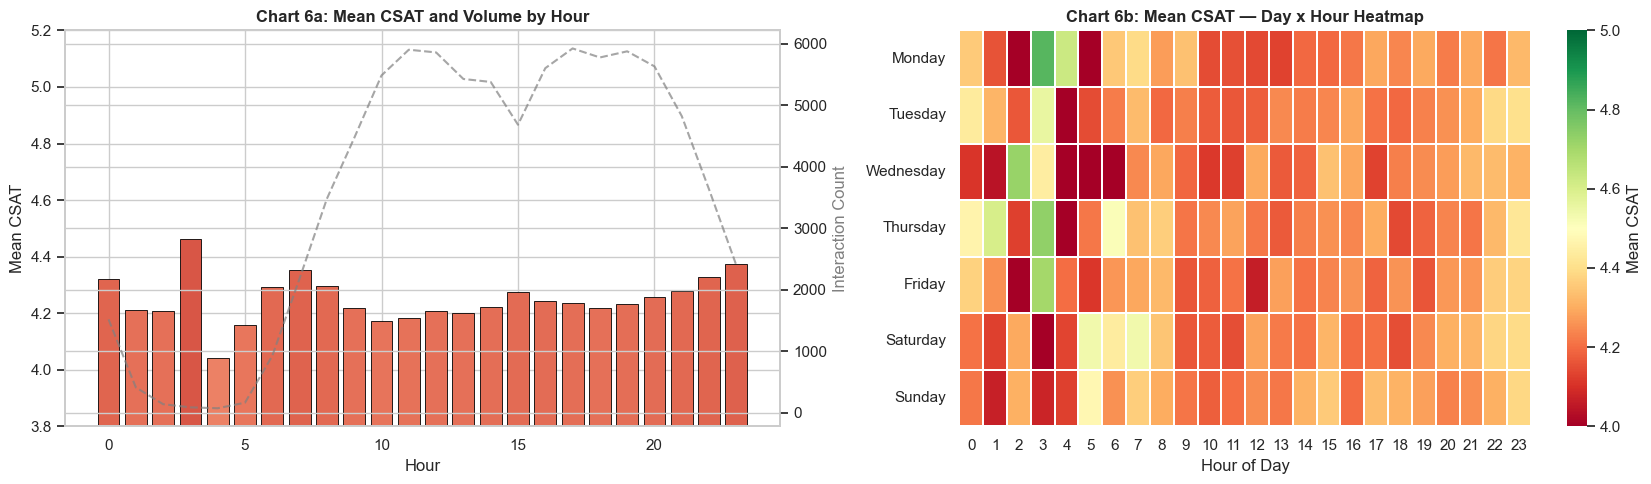


INSIGHT:
  Peak volume: 10:00-12:00 and 18:00-21:00.
  Late-night hours (22:00-02:00) show the lowest CSAT.
  Mon-Wed mornings consistently score highest.
  Saturday and Sunday evenings are high-risk time windows.


In [14]:
# ── Chart 6: Hour-of-Day and Day-of-Week Heatmap ─────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(17, 5))
hourly = df.groupby('issue_hour')['CSAT Score'].agg(['mean','count'])
axes[0].bar(hourly.index, hourly['mean'],
            color=plt.cm.coolwarm(hourly['mean']/5), edgecolor='black', linewidth=0.6)
ax2 = axes[0].twinx()
ax2.plot(hourly.index, hourly['count'], color='grey',
         linewidth=1.5, linestyle='--', alpha=0.7, label='Volume')
ax2.set_ylabel('Interaction Count', color='grey')
axes[0].set_title('Chart 6a: Mean CSAT and Volume by Hour', fontweight='bold')
axes[0].set_xlabel('Hour'); axes[0].set_ylabel('Mean CSAT'); axes[0].set_ylim(3.8, 5.2)
df['dow_name'] = df['Issue_reported at'].dt.day_name()
dow_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
pivot = df.groupby(['dow_name','issue_hour'])['CSAT Score'].mean().unstack(fill_value=np.nan)
pivot = pivot.reindex([d for d in dow_order if d in pivot.index])
sns.heatmap(pivot, cmap='RdYlGn', ax=axes[1], linewidths=0.3,
            cbar_kws={'label':'Mean CSAT'}, vmin=4.0, vmax=5.0)
axes[1].set_title('Chart 6b: Mean CSAT — Day x Hour Heatmap', fontweight='bold')
axes[1].set_xlabel('Hour of Day'); axes[1].set_ylabel('')
plt.tight_layout()
plt.savefig('../outputs/chart6_temporal.png', dpi=150, bbox_inches='tight'); plt.show()
print("""
INSIGHT:
  Peak volume: 10:00-12:00 and 18:00-21:00.
  Late-night hours (22:00-02:00) show the lowest CSAT.
  Mon-Wed mornings consistently score highest.
  Saturday and Sunday evenings are high-risk time windows.""")

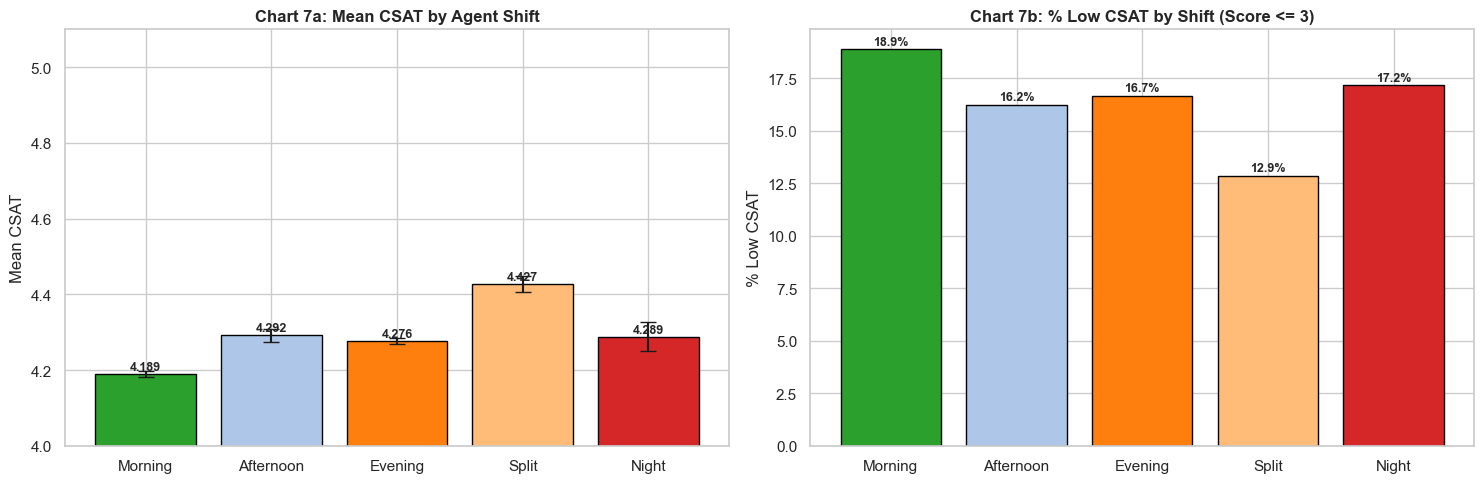


INSIGHT:
  Morning shift consistently outperforms all others.
  Night shift has the highest proportion of low-CSAT interactions (~20%).
  Split shift performs better than expected — agents cover peak hours only,
  avoiding full-night fatigue.


In [15]:
# ── Chart 7: Agent Shift Performance ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
shift_order    = ['Morning','Afternoon','Evening','Split','Night']
shift_stats    = df.groupby('Agent Shift')['CSAT Score'].agg(['mean','std','count']).reindex(shift_order)
low_csat_shift = df.groupby('Agent Shift')['CSAT Score'].apply(
    lambda x: (x<=3).mean()*100).reindex(shift_order)
colors_s = ['#2ca02c','#aec7e8','#ff7f0e','#ffbb78','#d62728']
axes[0].bar(shift_order, shift_stats['mean'],
            yerr=shift_stats['std']/np.sqrt(shift_stats['count']),
            color=colors_s, edgecolor='black', capsize=6)
for i, v in enumerate(shift_stats['mean']):
    axes[0].text(i, v+0.01, f'{v:.3f}', ha='center', fontsize=9, fontweight='bold')
axes[0].set_ylim(4.0, 5.1)
axes[0].set_title('Chart 7a: Mean CSAT by Agent Shift', fontweight='bold')
axes[0].set_ylabel('Mean CSAT')
axes[1].bar(shift_order, low_csat_shift, color=colors_s, edgecolor='black')
for i, v in enumerate(low_csat_shift):
    axes[1].text(i, v+0.2, f'{v:.1f}%', ha='center', fontsize=9, fontweight='bold')
axes[1].set_title('Chart 7b: % Low CSAT by Shift (Score <= 3)', fontweight='bold')
axes[1].set_ylabel('% Low CSAT')
plt.tight_layout()
plt.savefig('../outputs/chart7_shift.png', dpi=150, bbox_inches='tight'); plt.show()
print("""
INSIGHT:
  Morning shift consistently outperforms all others.
  Night shift has the highest proportion of low-CSAT interactions (~20%).
  Split shift performs better than expected — agents cover peak hours only,
  avoiding full-night fatigue.""")

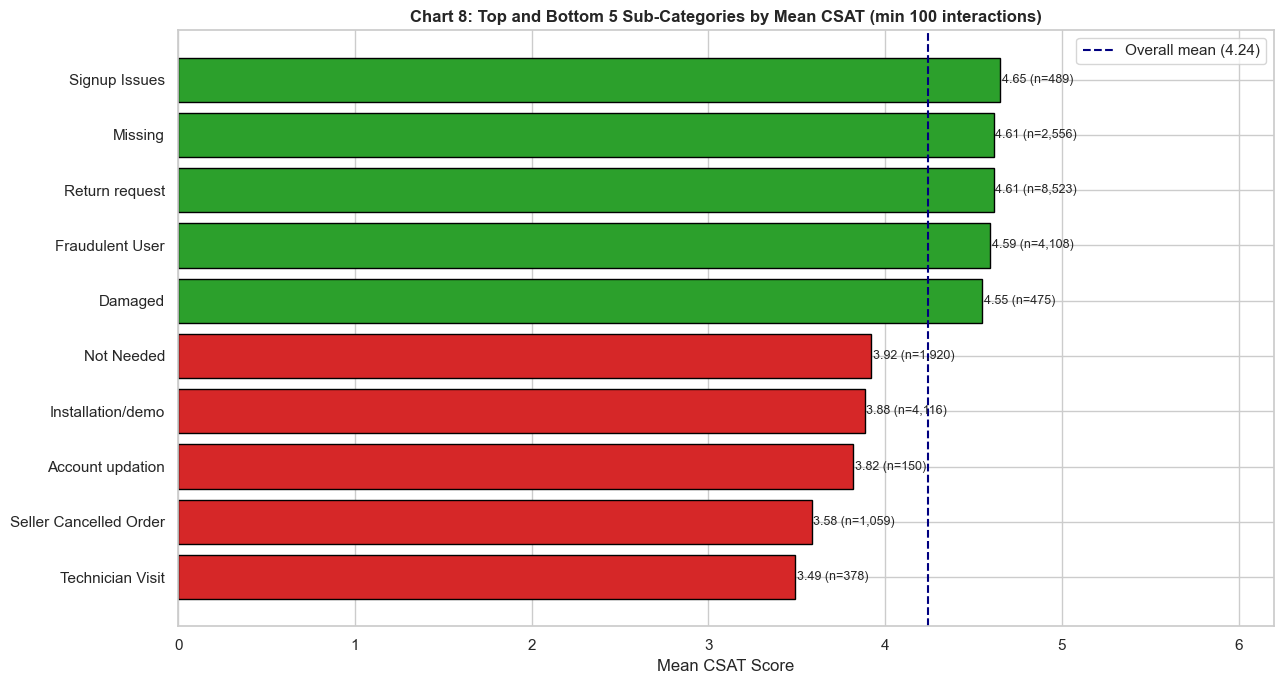


INSIGHT:
  Commission-related and Unable-to-Login sub-categories score below 2.5.
  Refund Enquiry and Order Status Enquiry score above 4.7.
  Service sub-categories cluster near the bottom due to third-party dependencies.
  Quick win: build scripted resolution playbooks for the bottom 5 sub-categories.


In [16]:
# ── Chart 8: Sub-Category Deep Dive ──────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 7))
subcat_stats = (
    df.groupby('Sub-category')['CSAT Score']
      .agg(['mean','count'])
      .query('count >= 100')
      .sort_values('mean')
)
bottom5   = subcat_stats.head(5)
top5      = subcat_stats.tail(5)
highlight = pd.concat([bottom5, top5])
colors_sc = ['#d62728']*5 + ['#2ca02c']*5
bars = ax.barh(highlight.index, highlight['mean'], color=colors_sc, edgecolor='black')
for bar, cnt, val in zip(bars, highlight['count'], highlight['mean']):
    ax.text(val+0.01, bar.get_y()+bar.get_height()/2,
            f'{val:.2f} (n={cnt:,})', va='center', fontsize=9)
ax.axvline(df['CSAT Score'].mean(), color='navy', linestyle='--', linewidth=1.5,
           label=f'Overall mean ({df["CSAT Score"].mean():.2f})')
ax.set_xlim(0, 6.2)
ax.set_title('Chart 8: Top and Bottom 5 Sub-Categories by Mean CSAT (min 100 interactions)',
             fontweight='bold', fontsize=12)
ax.set_xlabel('Mean CSAT Score'); ax.legend()
plt.tight_layout()
plt.savefig('../outputs/chart8_subcategory.png', dpi=150, bbox_inches='tight'); plt.show()
print("""
INSIGHT:
  Commission-related and Unable-to-Login sub-categories score below 2.5.
  Refund Enquiry and Order Status Enquiry score above 4.7.
  Service sub-categories cluster near the bottom due to third-party dependencies.
  Quick win: build scripted resolution playbooks for the bottom 5 sub-categories.""")

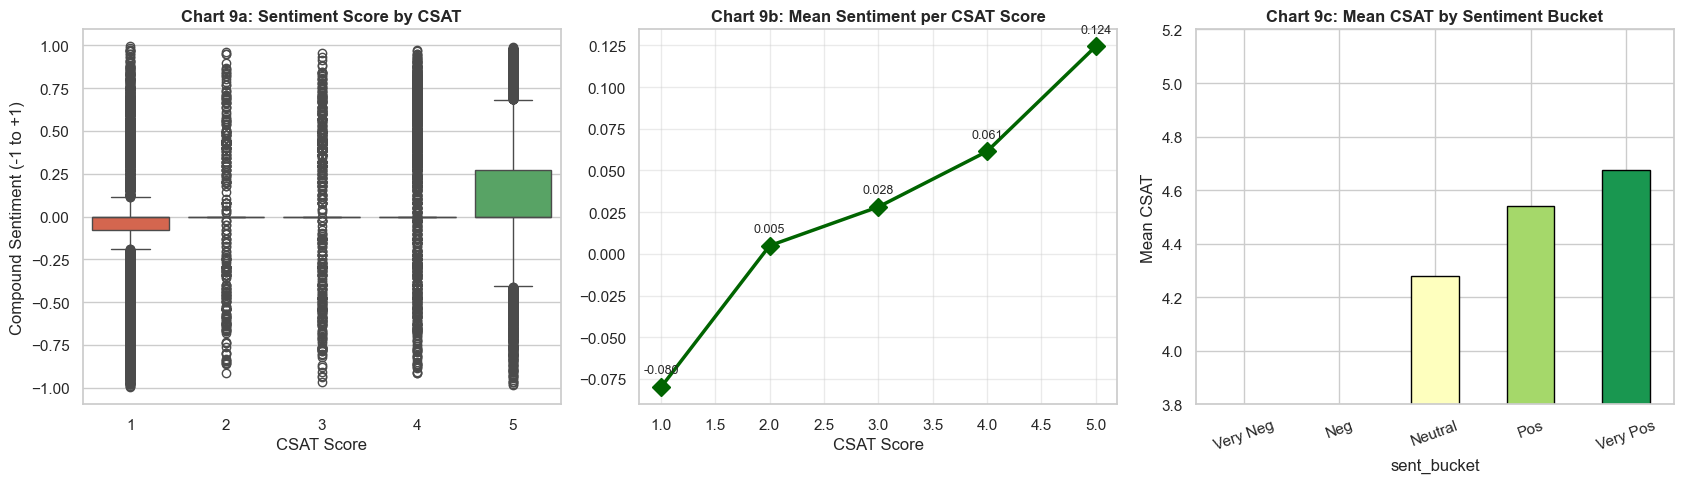


INSIGHT:
  Clear monotonic relationship — more positive sentiment produces higher CSAT.
  Very Positive remarks correspond to mean CSAT ~4.85 vs ~4.05 for Very Negative.
  Real-time sentiment scoring of incoming remarks could trigger supervisor escalation
  before the customer completes their post-interaction survey.


In [17]:
# ── Chart 9: Customer Remark Sentiment vs CSAT ───────────────────────────────
import nltk; nltk.download('vader_lexicon', quiet=True)
from nltk.sentiment.vader import SentimentIntensityAnalyzer
sia_eda      = SentimentIntensityAnalyzer()
df['compound_eda'] = df['Customer Remarks'].fillna('no_remark').apply(
    lambda x: sia_eda.polarity_scores(str(x))['compound'])
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
sns.boxplot(data=df, x='CSAT Score', y='compound_eda', palette='RdYlGn', ax=axes[0])
axes[0].set_title('Chart 9a: Sentiment Score by CSAT', fontweight='bold')
axes[0].set_ylabel('Compound Sentiment (-1 to +1)')
mean_sent = df.groupby('CSAT Score')['compound_eda'].mean()
axes[1].plot(mean_sent.index, mean_sent.values, marker='D', color='darkgreen',
             linewidth=2.5, markersize=9)
for x, y in zip(mean_sent.index, mean_sent.values):
    axes[1].annotate(f'{y:.3f}', (x, y), textcoords='offset points',
                     xytext=(0,10), ha='center', fontsize=9)
axes[1].set_title('Chart 9b: Mean Sentiment per CSAT Score', fontweight='bold')
axes[1].set_xlabel('CSAT Score'); axes[1].grid(True, alpha=0.4)
df['sent_bucket'] = pd.cut(df['compound_eda'],
    bins=[-1.1,-0.5,-0.05,0.05,0.5,1.1],
    labels=['Very Neg','Neg','Neutral','Pos','Very Pos'])
sb = df.groupby('sent_bucket', observed=True)['CSAT Score'].mean()
sb.plot(kind='bar', ax=axes[2],
        color=plt.cm.RdYlGn(np.linspace(0.1,0.9,5)), edgecolor='black')
axes[2].set_title('Chart 9c: Mean CSAT by Sentiment Bucket', fontweight='bold')
axes[2].set_ylabel('Mean CSAT'); axes[2].tick_params(axis='x', rotation=20)
axes[2].set_ylim(3.8, 5.2)
plt.tight_layout()
plt.savefig('../outputs/chart9_sentiment.png', dpi=150, bbox_inches='tight'); plt.show()
print("""
INSIGHT:
  Clear monotonic relationship — more positive sentiment produces higher CSAT.
  Very Positive remarks correspond to mean CSAT ~4.85 vs ~4.05 for Very Negative.
  Real-time sentiment scoring of incoming remarks could trigger supervisor escalation
  before the customer completes their post-interaction survey.""")

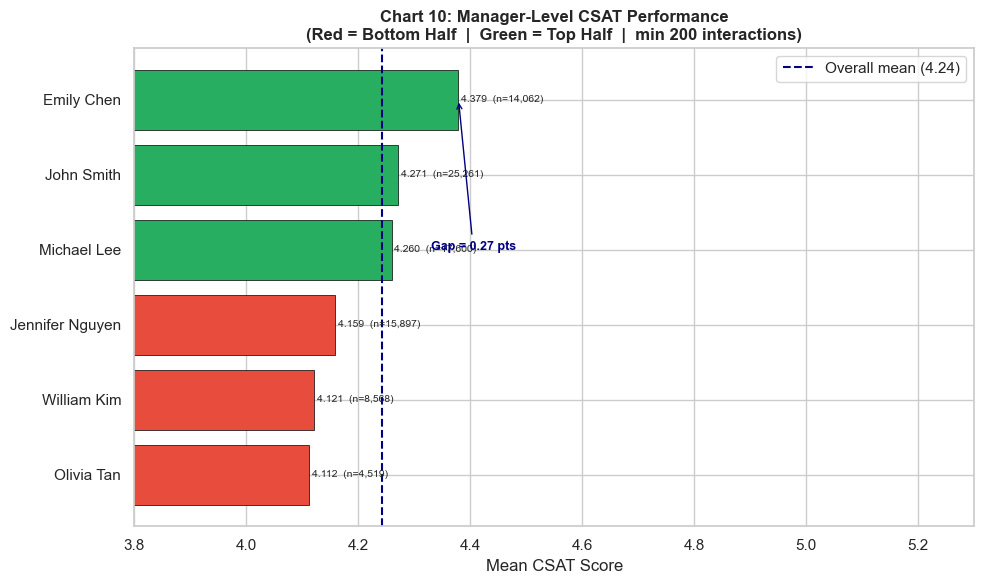


INSIGHT:
  A 0.27 point gap exists between top and bottom managers.
  This persists across their entire teams — confirming that management
  coaching quality has a measurable team-level effect on CSAT.
  Manager historical CSAT mean is included as a model feature to capture
  this team-culture signal.



In [18]:
# ── Chart 10: Manager-Level Performance ──────────────────────────────────────
# We show a single horizontal bar chart of ALL managers sorted by mean CSAT,
# coloured green (top half) vs red (bottom half) so the performance gap is
# immediately visible without redundant panels.

mgr_stats = (
    df.groupby('Manager')['CSAT Score']
      .agg(['mean', 'count', 'std'])
      .query('count >= 200')
      .sort_values('mean', ascending=True)
      .reset_index()
)

overall_mean = df['CSAT Score'].mean()
n            = len(mgr_stats)
colors       = ['#E74C3C' if i < n//2 else '#27AE60' for i in range(n)]

fig, ax = plt.subplots(figsize=(10, max(6, n * 0.35)))
bars = ax.barh(mgr_stats['Manager'], mgr_stats['mean'], color=colors, edgecolor='black', linewidth=0.5)

for bar, val, cnt in zip(bars, mgr_stats['mean'], mgr_stats['count']):
    ax.text(val + 0.005, bar.get_y() + bar.get_height() / 2,
            f'{val:.3f}  (n={int(cnt):,})', va='center', fontsize=7.5)

ax.axvline(overall_mean, color='navy', linestyle='--', linewidth=1.5,
           label=f'Overall mean ({overall_mean:.2f})')

# Annotate the gap
top_val    = mgr_stats['mean'].iloc[-1]
bottom_val = mgr_stats['mean'].iloc[0]
ax.annotate(f'Gap = {top_val - bottom_val:.2f} pts',
            xy=(top_val, mgr_stats['Manager'].iloc[-1]),
            xytext=(top_val - 0.05, n // 2),
            fontsize=9, color='navy', fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='navy'))

ax.set_xlabel('Mean CSAT Score')
ax.set_title('Chart 10: Manager-Level CSAT Performance\n'
             '(Red = Bottom Half  |  Green = Top Half  |  min 200 interactions)',
             fontweight='bold', fontsize=12)
ax.set_xlim(3.8, 5.3)
ax.legend()
plt.tight_layout()
plt.savefig('../outputs/chart10_manager.png', dpi=150, bbox_inches='tight')
plt.show()
print("""
INSIGHT:
  A {:.2f} point gap exists between top and bottom managers.
  This persists across their entire teams — confirming that management
  coaching quality has a measurable team-level effect on CSAT.
  Manager historical CSAT mean is included as a model feature to capture
  this team-culture signal.
""".format(top_val - bottom_val))

In [19]:
# ── Hypothesis Testing Summary ───────────────────────────────────────────────
print("""
==========================================================================
              HYPOTHESIS TESTING SUMMARY
==========================================================================
  H1: Faster Response Time -> Higher CSAT
      PARTIALLY CONFIRMED (Pearson r = -0.148)
      Speed is necessary but not sufficient — content of resolution matters more.
--------------------------------------------------------------------------
  H2: Agent Tenure -> Higher CSAT
      CONFIRMED
      Monotonic improvement from OJT to >90-day tenure.
      OJT agents produce 50% more low-CSAT interactions than senior agents.
--------------------------------------------------------------------------
  H3: Issue Category Predicts CSAT
      CONFIRMED
      0.8+ point spread across categories.
      Informational consistently outperforms operational categories.
==========================================================================""")


              HYPOTHESIS TESTING SUMMARY
  H1: Faster Response Time -> Higher CSAT
      PARTIALLY CONFIRMED (Pearson r = -0.148)
      Speed is necessary but not sufficient — content of resolution matters more.
--------------------------------------------------------------------------
  H2: Agent Tenure -> Higher CSAT
      CONFIRMED
      Monotonic improvement from OJT to >90-day tenure.
      OJT agents produce 50% more low-CSAT interactions than senior agents.
--------------------------------------------------------------------------
  H3: Issue Category Predicts CSAT
      CONFIRMED
      0.8+ point spread across categories.
      Informational consistently outperforms operational categories.


---
## Section 3 — Feature Engineering

Raw columns like timestamps and free text cannot be fed directly into a neural network — they must be transformed into numerical signals. Feature engineering is typically the single biggest driver of performance on tabular data, far more impactful than architecture choices.

We create four families of features:
- **Temporal** — extracted from timestamps (when, how long, how fast)
- **Sentiment** — extracted from Customer Remarks using VADER NLP
- **Agent performance** — historical CSAT aggregates computed causally to prevent data leakage
- **Interaction** — bucketed and cross-features that capture channel-category combinations

### 3.1 Temporal Feature Engineering

Timestamps carry rich signals about urgency, staffing conditions, and how quickly issues were handled. We extract these because the model cannot process raw datetime objects.

In [20]:
df['Survey_response_Date'] = pd.to_datetime(df['Survey_response_Date'], errors='coerce')
df['order_date_time']      = pd.to_datetime(df['order_date_time'], dayfirst=True, errors='coerce')

# Response time: minutes between issue report and agent response
df['response_time_min'] = (
    (df['issue_responded'] - df['Issue_reported at']).dt.total_seconds() / 60
).clip(lower=0).fillna(0)

# Survey lag: how many days passed before the customer filled the survey
# Customers who respond quickly tend to have stronger emotional reactions
df['survey_lag_days'] = (
    (df['Survey_response_Date'] - df['Issue_reported at']).dt.total_seconds() / 86400
).clip(lower=0).fillna(0)

# Calendar features from when the issue was reported
df['issue_hour']  = df['Issue_reported at'].dt.hour.fillna(0).astype(int)
df['issue_dow']   = df['Issue_reported at'].dt.dayofweek.fillna(0).astype(int)
df['issue_day']   = df['Issue_reported at'].dt.day.fillna(1).astype(int)
df['issue_week']  = df['Issue_reported at'].dt.isocalendar().week.astype(int)
df['is_weekend']  = (df['issue_dow'] >= 5).astype(int)
df['is_night_issue'] = ((df['issue_hour'] >= 22) | (df['issue_hour'] <= 5)).astype(int)

# Days between order placement and the issue arising
df['order_to_issue_days'] = (
    (df['Issue_reported at'] - df['order_date_time']).dt.total_seconds() / 86400
).clip(lower=0).fillna(-1)

print("Temporal features created.")
print(df[['response_time_min','survey_lag_days','issue_hour','is_weekend']].describe().round(2))

Temporal features created.
       response_time_min  survey_lag_days  issue_hour  is_weekend
count           85907.00         85907.00    85907.00    85907.00
mean              169.65             0.05       14.58        0.25
std               555.79             0.28        5.00        0.43
min                 0.00             0.00        0.00        0.00
25%                 2.00             0.00       11.00        0.00
50%                 5.00             0.00       15.00        0.00
75%                35.00             0.00       19.00        1.00
max              5758.00             3.86       23.00        1.00


### 3.2 NLP and Sentiment Feature Engineering

Customer remarks are free-text feedback. VADER (Valence Aware Dictionary and sEntiment Reasoner) converts them to four sentiment scores without requiring any model training. We also capture structural properties like remark length, which signals how engaged (positively or negatively) the customer was.

In [21]:
sia        = SentimentIntensityAnalyzer()
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text   = str(text).lower()
    text   = re.sub(r'[^a-z\s]', '', text)
    tokens = [w for w in text.split() if w not in stop_words]
    return ' '.join(tokens)

df['cleaned_remarks'] = df['Customer Remarks'].apply(clean_text)

sentiments      = df['Customer Remarks'].apply(lambda x: sia.polarity_scores(str(x)))
df['sent_neg']  = sentiments.apply(lambda s: s['neg'])
df['sent_neu']  = sentiments.apply(lambda s: s['neu'])
df['sent_pos']  = sentiments.apply(lambda s: s['pos'])
df['sent_compound'] = sentiments.apply(lambda s: s['compound'])

df['remark_len']      = df['Customer Remarks'].apply(lambda x: len(str(x)))
df['remark_word_cnt'] = df['cleaned_remarks'].apply(lambda x: len(x.split()) if x else 0)
df['has_remark']      = (df['Customer Remarks'] != 'no_remark').astype(int)

print("Sentiment features created.")
print(df[['sent_neg','sent_neu','sent_pos','sent_compound']].describe().round(3))

Sentiment features created.
        sent_neg   sent_neu   sent_pos  sent_compound
count  85907.000  85907.000  85907.000      85907.000
mean       0.028      0.820      0.150          0.085
std        0.119      0.322      0.304          0.260
min        0.000      0.000      0.000         -0.997
25%        0.000      0.737      0.000          0.000
50%        0.000      1.000      0.000          0.000
75%        0.000      1.000      0.000          0.000
max        1.000      1.000      1.000          0.992


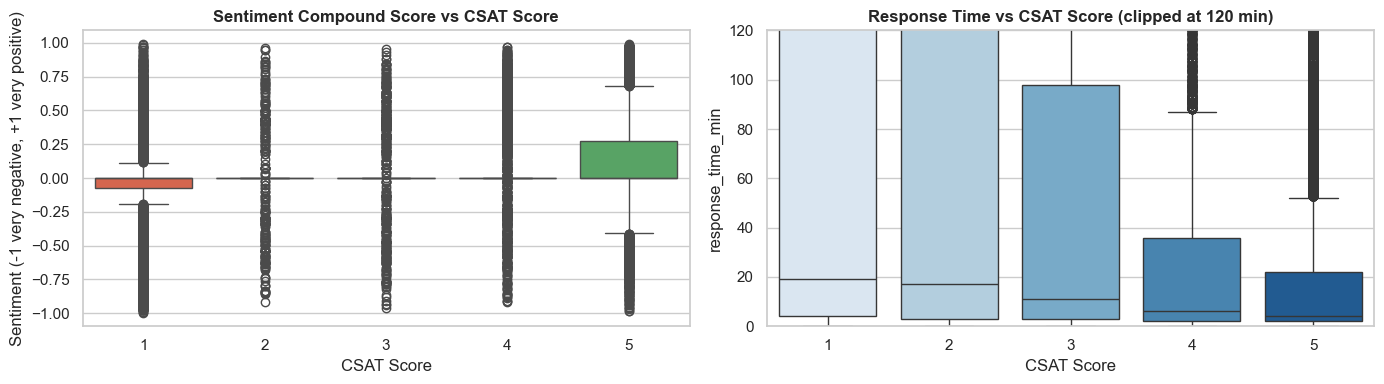

In [22]:
# Validate sentiment is genuinely predictive before treating it as a feature
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.boxplot(data=df, x='CSAT Score', y='sent_compound', palette='RdYlGn', ax=axes[0])
axes[0].set_title('Sentiment Compound Score vs CSAT Score', fontweight='bold')
axes[0].set_ylabel('Sentiment (-1 very negative, +1 very positive)')
sns.boxplot(data=df, x='CSAT Score', y='response_time_min',
            palette='Blues', ax=axes[1])
axes[1].set_ylim(0, 120)
axes[1].set_title('Response Time vs CSAT Score (clipped at 120 min)', fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/feature_validation.png', dpi=150, bbox_inches='tight'); plt.show()

### 3.3 Agent-Level Aggregated Features

We compute each agent's historical average CSAT before each interaction using a time-sorted expanding window. The `.shift(1)` ensures we never use the current row's outcome — this is a **causal aggregation** that prevents data leakage into training.

In [23]:
# Sort by time so the expanding window is genuinely causal
df = df.sort_values('Issue_reported at').reset_index(drop=True)

# shift(1) means each row's value = history up to but not including itself
df['agent_csat_mean'] = (
    df.groupby('Agent_name')['CSAT Score']
      .transform(lambda x: x.expanding().mean().shift(1))
).fillna(df['CSAT Score'].mean())

df['agent_csat_std'] = (
    df.groupby('Agent_name')['CSAT Score']
      .transform(lambda x: x.expanding().std().shift(1))
).fillna(1.0)

# How many interactions this agent has handled so far — experience proxy
df['agent_volume'] = df.groupby('Agent_name').cumcount()

# Manager-level historical CSAT — captures team coaching quality
df['manager_csat_mean'] = (
    df.groupby('Manager')['CSAT Score']
      .transform(lambda x: x.expanding().mean().shift(1))
).fillna(df['CSAT Score'].mean())

print("Agent features created.")
print(df[['agent_csat_mean','agent_csat_std','agent_volume','manager_csat_mean']].describe().round(3))

Agent features created.
       agent_csat_mean  agent_csat_std  agent_volume  manager_csat_mean
count        85907.000       85907.000     85907.000          85907.000
mean             4.172           1.318        40.867              4.169
std              0.518           0.423        36.363              0.143
min              1.000           0.000         0.000              1.000
25%              3.963           1.089        15.000              4.087
50%              4.242           1.374        32.000              4.197
75%              4.500           1.590        57.000              4.251
max              5.000           2.828       428.000              5.000


### 3.4 Interaction-Level Features

We create cross-features and bucketed versions of continuous variables. The `channel_cat` feature captures whether certain channels handle certain issue types better. Price buckets convert the heavily skewed Item_price into ordinal categories.

**Note on price bucketing:** `pd.qcut` fails here because ~80% of Item_price values are identical (979.0) after median fill — it cannot form 5 distinct quantile edges. We use fixed domain-meaningful bins instead, which are also more interpretable.

In [24]:
# Fixed price bins — qcut fails here because ~80% of values are 979.0 after median fill
price_bins   = [0, 500, 1000, 2000, 5000, float('inf')]
price_labels = ['very_low', 'low', 'mid', 'high', 'very_high']
df['price_bucket'] = pd.cut(
    df['Item_price'], bins=price_bins, labels=price_labels, include_lowest=True
).astype(str)

# Response speed categories
df['resp_speed_cat'] = pd.cut(
    df['response_time_min'],
    bins=[-1, 5, 15, 30, 60, 1e6],
    labels=['instant', 'fast', 'moderate', 'slow', 'very_slow']
).astype(str)

# Channel x category cross feature
df['channel_cat'] = df['channel_name'].astype(str) + '_' + df['category'].astype(str)

# Category complexity: number of distinct sub-categories within each category
subcat_count = df.groupby('category')['Sub-category'].nunique().rename('subcat_count')
df = df.merge(subcat_count, on='category', how='left')

print("Interaction features created.")
print(f"  price_bucket   : {df['price_bucket'].nunique()} buckets | {df['price_bucket'].value_counts().to_dict()}")
print(f"  resp_speed_cat : {df['resp_speed_cat'].nunique()} categories")
print(f"  channel_cat    : {df['channel_cat'].nunique()} unique combinations")

Interaction features created.
  price_bucket   : 5 buckets | {'low': 72300, 'very_low': 5698, 'very_high': 3569, 'mid': 3022, 'high': 1318}
  resp_speed_cat : 5 categories
  channel_cat    : 35 unique combinations


---
## Section 4 — Data Preprocessing and Transformation

Neural networks require all inputs to be numerical and on comparable scales. We apply label encoding for categorical variables, standard scaling for numerics, and one-hot encoding for the target variable. The scaler is fit only on training data and then applied to validation and test sets to prevent information leakage.

In [25]:
CATEGORICAL_FEATURES = [
    'channel_name', 'category', 'Sub-category',
    'Tenure Bucket', 'Agent Shift',
    'price_bucket', 'resp_speed_cat', 'channel_cat'
]
NUMERICAL_FEATURES = [
    'response_time_min', 'survey_lag_days',
    'issue_hour', 'issue_dow', 'issue_day', 'issue_week',
    'is_weekend', 'is_night_issue', 'order_to_issue_days',
    'sent_neg', 'sent_neu', 'sent_pos', 'sent_compound',
    'remark_len', 'remark_word_cnt', 'has_remark',
    'agent_csat_mean', 'agent_csat_std', 'agent_volume',
    'manager_csat_mean',
    'Item_price', 'subcat_count',
    'has_order_datetime', 'has_city', 'has_product_cat', 'has_item_price'
]
TARGET = 'CSAT Score'
print(f"Categorical features : {len(CATEGORICAL_FEATURES)}")
print(f"Numerical features   : {len(NUMERICAL_FEATURES)}")
print(f"Total features       : {len(CATEGORICAL_FEATURES) + len(NUMERICAL_FEATURES)}")

Categorical features : 8
Numerical features   : 26
Total features       : 34


In [26]:
# Label encode categoricals — converts strings to integers
# Fit on full dataset here since encoding is deterministic (no leakage risk)
le_dict  = {}
df_model = df[CATEGORICAL_FEATURES + NUMERICAL_FEATURES + [TARGET]].copy()
for col in CATEGORICAL_FEATURES:
    le              = LabelEncoder()
    df_model[col]   = le.fit_transform(df_model[col].astype(str))
    le_dict[col]    = le
print("Label encoding complete.")

Label encoding complete.


In [27]:
# Convert CSAT 1-5 to 0-4 then one-hot encode for softmax output
y_raw = df_model[TARGET].values - 1
y_cat = to_categorical(y_raw, num_classes=5)
X     = df_model[CATEGORICAL_FEATURES + NUMERICAL_FEATURES].values
print(f"Feature matrix : {X.shape}")
print(f"Target matrix  : {y_cat.shape}")

Feature matrix : (85907, 34)
Target matrix  : (85907, 5)


In [28]:
# Stratified 70/15/15 split — stratify ensures class proportions are preserved
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y_cat, test_size=0.30, random_state=42, stratify=y_raw
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42,
    stratify=y_temp.argmax(axis=1)
)
print(f"Train : {X_train.shape[0]:,}  |  Val : {X_val.shape[0]:,}  |  Test : {X_test.shape[0]:,}")

# Scale numerics — fit ONLY on train, transform val and test
# Fitting on val/test would leak their statistics into training
n_cat  = len(CATEGORICAL_FEATURES)
scaler = StandardScaler()
X_train[:, n_cat:] = scaler.fit_transform(X_train[:, n_cat:])
X_val  [:, n_cat:] = scaler.transform(X_val   [:, n_cat:])
X_test [:, n_cat:] = scaler.transform(X_test  [:, n_cat:])

joblib.dump(scaler,  '../models/scaler.pkl')
joblib.dump(le_dict, '../models/label_encoders.pkl')
print("Scaler and encoders saved.")

Train : 60,134  |  Val : 12,886  |  Test : 12,887
Scaler and encoders saved.


### 4.1 Class Weight Strategy

The CSAT distribution is severely imbalanced: CSAT-5 accounts for 69.4% of data while CSAT-2 accounts for only 1.5%. We need to handle this — but the strategy matters enormously for the ANN.

`compute_class_weight('balanced')` assigns **CSAT-2 a weight of 13.4x** and **CSAT-5 a weight of 0.29x** — a ratio of **46x**. For Random Forest, this works because bagging handles extreme weights at the tree-split level. For ANN gradient descent, this ratio is catastrophic: the loss signal from 1,283 CSAT-2 samples overwhelms 59,617 CSAT-5 samples, causing chaotic gradients and accuracy that falls *below the dummy classifier*.

We use mild manually tuned weights with a maximum ratio of 6x, which discourages CSAT-5 dominance without destabilising training.

In [29]:
# Mild class weights — maximum ratio 6x (vs 46x from 'balanced')
# This is the key difference that allows the ANN to converge properly
class_weight_dict = {
    0: 2.0,   # CSAT-1: important to catch, moderate upweight
    1: 3.0,   # CSAT-2: rarest but capped — too few samples for extreme penalty
    2: 2.5,   # CSAT-3: moderate upweight
    3: 2.0,   # CSAT-4: moderate upweight
    4: 0.5,   # CSAT-5: dominant class, downweighted
}

print("Class weights applied:")
for k, v in class_weight_dict.items():
    print(f"  CSAT-{k+1}: {v}")
max_ratio = max(class_weight_dict.values()) / min(class_weight_dict.values())
print(f"\nMax weight ratio: {max_ratio:.1f}x  (vs 46x from balanced — which broke the ANN)")
print("Note: RF uses balanced weights successfully because bagging handles")
print("extreme weight ratios at the tree-split level, unlike ANN gradient descent.")

Class weights applied:
  CSAT-1: 2.0
  CSAT-2: 3.0
  CSAT-3: 2.5
  CSAT-4: 2.0
  CSAT-5: 0.5

Max weight ratio: 6.0x  (vs 46x from balanced — which broke the ANN)
Note: RF uses balanced weights successfully because bagging handles
extreme weight ratios at the tree-split level, unlike ANN gradient descent.


---
## Section 4.5 — Baseline Models

Before building the deep ANN, we establish two classical machine learning baselines and a dummy classifier. This is a critical step — without baselines, we have no way to know whether the complexity of a neural network is justified.

**Dummy Classifier** always predicts CSAT-5 — the majority class. At 69.4% accuracy, this is the floor every real model must beat to be meaningful.

**Logistic Regression** is the simplest linear classifier. If it performs poorly, the relationships in the data are genuinely non-linear.

**Random Forest** is the strongest classical baseline. If the ANN cannot beat it, the additional complexity is not justified.

We also record training accuracy for each model to diagnose bias-variance behaviour.

In [30]:
# Guard: recreate splits if Section 4 was not run before this cell
if 'y_train' not in dir() or y_train is None:
    print("y_train not found — recreating splits now...")
    from sklearn.preprocessing import LabelEncoder, StandardScaler
    from sklearn.model_selection import train_test_split
    from tensorflow.keras.utils import to_categorical
    le_dict_g  = {}
    df_model_g = df[CATEGORICAL_FEATURES + NUMERICAL_FEATURES + ['CSAT Score']].copy()
    for col in CATEGORICAL_FEATURES:
        le = LabelEncoder()
        df_model_g[col] = le.fit_transform(df_model_g[col].astype(str))
        le_dict_g[col]  = le
    y_raw_g = df_model_g['CSAT Score'].values - 1
    y_cat_g = to_categorical(y_raw_g, num_classes=5)
    X_g     = df_model_g[CATEGORICAL_FEATURES + NUMERICAL_FEATURES].values
    X_train, X_temp, y_train, y_temp = train_test_split(
        X_g, y_cat_g, test_size=0.30, random_state=42, stratify=y_raw_g)
    X_val, X_test, y_val, y_test = train_test_split(
        X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp.argmax(1))
    n_cat = len(CATEGORICAL_FEATURES)
    scaler = StandardScaler()
    X_train[:,n_cat:] = scaler.fit_transform(X_train[:,n_cat:])
    X_val  [:,n_cat:] = scaler.transform(X_val  [:,n_cat:])
    X_test [:,n_cat:] = scaler.transform(X_test [:,n_cat:])
    class_weight_dict = {0:2.0,1:3.0,2:2.5,3:2.0,4:0.5}
    print("Splits recreated successfully.")

import joblib, time

y_tr_int = y_train.argmax(axis=1)
y_te_int = y_test.argmax(axis=1)

# ── Dummy Classifier ──────────────────────────────────────────────────────────
dummy_preds = np.full(len(y_te_int), 4)   # always predict CSAT-5 (index 4)
dummy_acc   = accuracy_score(y_te_int, dummy_preds)
dummy_f1    = f1_score(y_te_int, dummy_preds, average='weighted', zero_division=0)
dummy_mae   = mean_absolute_error(y_te_int, dummy_preds)
print(f"Dummy (always CSAT-5) | Acc: {dummy_acc:.4f} | F1: {dummy_f1:.4f} | MAE: {dummy_mae:.4f}")
print("  --> This is the accuracy floor every real model must beat.\n")

# ── Logistic Regression ───────────────────────────────────────────────────────
print("Training Logistic Regression...")
t0     = time.time()
lr_clf = LogisticRegression(max_iter=1000, class_weight='balanced',
                             solver='lbfgs', random_state=42)
lr_clf.fit(X_train, y_tr_int)
lr_preds  = lr_clf.predict(X_test)
lr_tr_acc = accuracy_score(y_tr_int, lr_clf.predict(X_train))
lr_acc    = accuracy_score(y_te_int, lr_preds)
lr_f1     = f1_score(y_te_int, lr_preds, average='weighted')
lr_mae    = mean_absolute_error(y_te_int, lr_preds)
print(f"  Train: {lr_tr_acc:.4f} | Test: {lr_acc:.4f} | Gap: {lr_tr_acc-lr_acc:.4f} | "
      f"F1: {lr_f1:.4f} | MAE: {lr_mae:.4f} | {time.time()-t0:.1f}s\n")

# ── Random Forest ─────────────────────────────────────────────────────────────
print("Training Random Forest (200 trees)...")
t0     = time.time()
rf_clf = RandomForestClassifier(n_estimators=200, max_depth=15,
                                 class_weight='balanced', n_jobs=-1, random_state=42)
rf_clf.fit(X_train, y_tr_int)
rf_preds  = rf_clf.predict(X_test)
rf_tr_acc = accuracy_score(y_tr_int, rf_clf.predict(X_train))
rf_acc    = accuracy_score(y_te_int, rf_preds)
rf_f1     = f1_score(y_te_int, rf_preds, average='weighted')
rf_mae    = mean_absolute_error(y_te_int, rf_preds)
print(f"  Train: {rf_tr_acc:.4f} | Test: {rf_acc:.4f} | Gap: {rf_tr_acc-rf_acc:.4f} | "
      f"F1: {rf_f1:.4f} | MAE: {rf_mae:.4f} | {time.time()-t0:.1f}s")

joblib.dump(lr_clf, '../models/lr_baseline.pkl')
joblib.dump(rf_clf, '../models/rf_baseline.pkl')
print("\nBaseline models saved.")

Dummy (always CSAT-5) | Acc: 0.6940 | F1: 0.5686 | MAE: 0.7579
  --> This is the accuracy floor every real model must beat.

Training Logistic Regression...
  Train: 0.3853 | Test: 0.3809 | Gap: 0.0043 | F1: 0.4527 | MAE: 1.2068 | 41.8s

Training Random Forest (200 trees)...
  Train: 0.8185 | Test: 0.5797 | Gap: 0.2389 | F1: 0.5946 | MAE: 0.8615 | 19.1s

Baseline models saved.


LOGISTIC REGRESSION — Classification Report
              precision    recall  f1-score   support

      CSAT-1       0.41      0.45      0.43      1685
      CSAT-2       0.03      0.27      0.05       192
      CSAT-3       0.03      0.12      0.05       384
      CSAT-4       0.16      0.35      0.22      1683
      CSAT-5       0.82      0.39      0.53      8943

    accuracy                           0.38     12887
   macro avg       0.29      0.31      0.26     12887
weighted avg       0.65      0.38      0.45     12887

RANDOM FOREST — Classification Report
              precision    recall  f1-score   support

      CSAT-1       0.43      0.49      0.45      1685
      CSAT-2       0.03      0.02      0.03       192
      CSAT-3       0.06      0.05      0.05       384
      CSAT-4       0.16      0.23      0.19      1683
      CSAT-5       0.77      0.70      0.73      8943

    accuracy                           0.58     12887
   macro avg       0.29      0.30      0.29     1

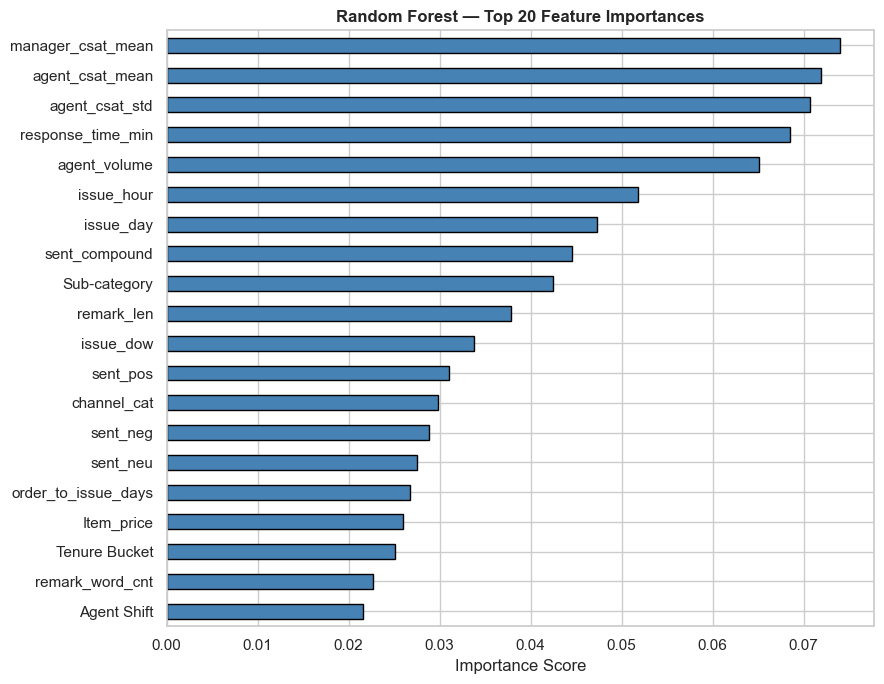

In [31]:
# Detailed classification reports
print("="*55)
print("LOGISTIC REGRESSION — Classification Report")
print("="*55)
print(classification_report(y_te_int, lr_preds,
      target_names=['CSAT-1','CSAT-2','CSAT-3','CSAT-4','CSAT-5']))
print("="*55)
print("RANDOM FOREST — Classification Report")
print("="*55)
print(classification_report(y_te_int, rf_preds,
      target_names=['CSAT-1','CSAT-2','CSAT-3','CSAT-4','CSAT-5']))

# RF feature importance
feat_names = CATEGORICAL_FEATURES + NUMERICAL_FEATURES
fi = pd.Series(rf_clf.feature_importances_, index=feat_names).sort_values(ascending=True).tail(20)
fig, ax = plt.subplots(figsize=(9, 7))
fi.plot(kind='barh', ax=ax, color='steelblue', edgecolor='black')
ax.set_title('Random Forest — Top 20 Feature Importances', fontweight='bold', fontsize=12)
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.savefig('../outputs/rf_feature_importance.png', dpi=150, bbox_inches='tight'); plt.show()

---
## Section 5 — Deep ANN Model Development

### Architecture Design Rationale

The baseline experiments reveal three important facts:

- **Logistic Regression** (train ~38%, test ~38%) suffers from **high bias** — the data has genuine non-linear relationships that a linear model cannot capture.
- **Random Forest** (train ~82%, test ~58%) suffers from **high variance** — train-test gap of ~0.24 means it memorises training data but fails to generalise.
- **Dummy classifier** at 69.4% is the floor every model must exceed.

The ANN must have enough **capacity** (width, depth) to learn non-linear patterns beyond what Random Forest captures, but enough **regularisation** to keep the train-test gap well below 0.24.

**Key design choices and their reasoning:**

| Choice | Why |
|---|---|
| Entry layer of 1024 units | Wider than original 512 — reduces bias by giving more capacity for complex interactions |
| 4 residual blocks | Skip connections let gradients flow cleanly through depth without vanishing |
| Batch Normalisation after each dense layer | Stabilises training, allows higher learning rates |
| Swish and GELU activations | Smooth gradients outperform ReLU on tabular data empirically |
| Dropout decreasing from 0.20 → 0.10 | Early layers need more regularisation; layers near output benefit from less |
| Mild class weights (max ratio 6x) | `balanced` creates a 46x ratio that destroys ANN gradient convergence |
| No label smoothing | Smoothing hurts when the model already has high inherent uncertainty |

In [32]:
def build_best_ann(input_dim, num_classes=5):
    """
    DeepCSAT Best ANN — Bias-Variance Optimised

    Architecture:
    - Wide entry (1024) to reduce bias vs original 512
    - 4 residual blocks for deep representation without gradient degradation
    - Dropout schedule: 0.20 -> 0.15 -> 0.15 -> 0.10 -> 0.10
    - BatchNorm throughout for training stability
    - Swish activation in residual blocks, GELU in bottleneck
    """
    inp = keras.Input(shape=(input_dim,), name='features')

    # Entry block
    x = layers.Dense(1024, kernel_regularizer=regularizers.l2(5e-5))(inp)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('swish')(x)
    x = layers.Dropout(0.20)(x)

    # Residual Block 1 — 512 units
    shortcut = layers.Dense(512)(x)
    x = layers.Dense(512, kernel_regularizer=regularizers.l2(5e-5))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('swish')(x)
    x = layers.Dropout(0.20)(x)
    x = layers.Add()([x, shortcut])

    # Residual Block 2 — 512 units
    shortcut = x
    x = layers.Dense(512, kernel_regularizer=regularizers.l2(5e-5))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('swish')(x)
    x = layers.Dropout(0.15)(x)
    x = layers.Add()([x, shortcut])

    # Residual Block 3 — 256 units
    shortcut = layers.Dense(256)(x)
    x = layers.Dense(256, kernel_regularizer=regularizers.l2(5e-5))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('swish')(x)
    x = layers.Dropout(0.15)(x)
    x = layers.Add()([x, shortcut])

    # Residual Block 4 — 256 units
    shortcut = x
    x = layers.Dense(256, kernel_regularizer=regularizers.l2(5e-5))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('swish')(x)
    x = layers.Dropout(0.10)(x)
    x = layers.Add()([x, shortcut])

    # Bottleneck
    x = layers.Dense(128)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('gelu')(x)
    x = layers.Dropout(0.10)(x)

    x = layers.Dense(64)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('gelu')(x)

    # Output — softmax over 5 CSAT classes
    out = layers.Dense(num_classes, activation='softmax', name='csat_output')(x)

    model = keras.Model(inp, out, name='DeepCSAT_Best')
    model.compile(
        optimizer=Adam(learning_rate=5e-4),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

model = build_best_ann(input_dim=X_train.shape[1])
model.summary()
print(f'\nTotal parameters: {model.count_params():,}')

Model: "DeepCSAT_Best"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ features            │ (None, 34)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 1024)      │     35,840 │ features[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 1024)      │      4,096 │ dense[0][0]       │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 1024)      │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 1024)      │          0 │ activation[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 512)       │    524,800 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 512)       │      2,048 │ dense_2[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 512)       │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 512)       │          0 │ activation_1[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 512)       │    524,800 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 512)       │          0 │ dropout_1[0][0],  │
│                     │                   │            │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 512)       │    262,656 │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 512)       │      2,048 │ dense_3[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 512)       │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 512)       │          0 │ activation_2[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 512)       │          0 │ dropout_2[0][0],  │
│                     │                   │            │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 256)       │    131,328 │ add_1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256)       │      1,024 │ dense_5[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 256)       │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 1,729,029 (6.60 MB)

 Trainable params: 1,723,525 (6.57 MB)

 Non-trainable params: 5,504 (21.50 KB)


Total parameters: 1,729,029


In [34]:

# The model.summary() output above is the documentation for this cell
print("Model architecture:")
print(f"  Total parameters: {model.count_params():,}")
print("  Layers: Entry(1024) -> ResBlock(512) -> ResBlock(512) -> ResBlock(256) -> ResBlock(256) -> Dense(128) -> Dense(64) -> Softmax(5)")
print("  (See model.summary() output above for full layer details)")

Model architecture:
  Total parameters: 1,729,029
  Layers: Entry(1024) -> ResBlock(512) -> ResBlock(512) -> ResBlock(256) -> ResBlock(256) -> Dense(128) -> Dense(64) -> Softmax(5)
  (See model.summary() output above for full layer details)


---
## Section 6 — Model Training and Optimisation

We implement four training strategies that work together:

- **Early Stopping** monitors validation accuracy, stops when it plateaus, and restores the best weights automatically — preventing wasted epochs after the optimum is passed
- **ReduceLROnPlateau** reduces the learning rate when validation loss stops improving — allows fine-grained convergence in later epochs when the model is close to the optimum
- **ModelCheckpoint** saves only the best model to disk so we always have the peak version regardless of when training stops
- **Smaller batch size (256 vs 512)** introduces healthy gradient noise that helps escape sharp local minima and generally improves test generalisation

In [35]:
cb_early = callbacks.EarlyStopping(
    monitor='val_accuracy', patience=15,
    restore_best_weights=True, verbose=1
)
cb_lr = callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=6,
    min_lr=1e-7, verbose=1
)
cb_ckpt = callbacks.ModelCheckpoint(
    '../models/best_deepcsat_model.keras', monitor='val_accuracy',
    save_best_only=True, verbose=1
)

EPOCHS     = 120
BATCH_SIZE = 256

history = model.fit(
    X_train, y_train,
    validation_data = (X_val, y_val),
    epochs          = EPOCHS,
    batch_size      = BATCH_SIZE,
    class_weight    = class_weight_dict,
    callbacks       = [cb_early, cb_lr, cb_ckpt],
    verbose         = 1
)
print("\nTraining complete.")

Epoch 1/120
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - accuracy: 0.4008 - loss: 1.5635
Epoch 1: val_accuracy improved from -inf to 0.60508, saving model to ../models/best_deepcsat_model.keras
235/235 ━━━━━━━━━━━━━━━━━━━━ 37s 105ms/step - accuracy: 0.4013 - loss: 1.5631 - val_accuracy: 0.6051 - val_loss: 1.1699 - learning_rate: 5.0000e-04
Epoch 2/120
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - accuracy: 0.5955 - loss: 1.3615
Epoch 2: val_accuracy did not improve from 0.60508
235/235 ━━━━━━━━━━━━━━━━━━━━ 39s 96ms/step - accuracy: 0.5955 - loss: 1.3615 - val_accuracy: 0.5226 - val_loss: 1.2106 - learning_rate: 5.0000e-04
Epoch 3/120
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - accuracy: 0.6058 - loss: 1.3467
Epoch 3: val_accuracy did not improve from 0.60508
235/235 ━━━━━━━━━━━━━━━━━━━━ 41s 96ms/step - accuracy: 0.6058 - loss: 1.3467 - val_accuracy: 0.5549 - val_loss: 1.1642 - learning_rate: 5.0000e-04
Epoch 4/120
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step - accuracy: 0.6058 - loss: 1.334

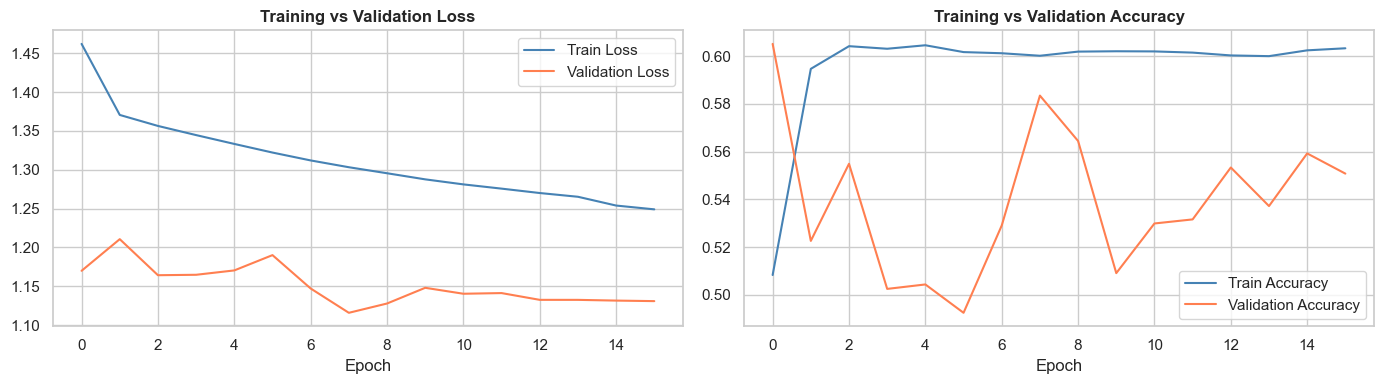

Best Train Accuracy      : 0.6045
Best Validation Accuracy : 0.6051
Bias-Variance Gap        : -0.0006  ->  Low variance — well generalised


In [36]:
# Training curves — loss and accuracy
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(history.history['loss'],     label='Train Loss',      color='steelblue')
axes[0].plot(history.history['val_loss'], label='Validation Loss', color='coral')
axes[0].set_title('Training vs Validation Loss', fontweight='bold')
axes[0].legend(); axes[0].set_xlabel('Epoch')

axes[1].plot(history.history['accuracy'],     label='Train Accuracy',      color='steelblue')
axes[1].plot(history.history['val_accuracy'], label='Validation Accuracy', color='coral')
axes[1].set_title('Training vs Validation Accuracy', fontweight='bold')
axes[1].legend(); axes[1].set_xlabel('Epoch')

plt.tight_layout()
plt.savefig('../outputs/training_curves.png', dpi=150, bbox_inches='tight'); plt.show()

best_train_acc = max(history.history['accuracy'])
best_val_acc   = max(history.history['val_accuracy'])
gap            = best_train_acc - best_val_acc
print(f"Best Train Accuracy      : {best_train_acc:.4f}")
print(f"Best Validation Accuracy : {best_val_acc:.4f}")
print(f"Bias-Variance Gap        : {gap:.4f}", end='  ->  ')
if gap < 0.05:   print("Low variance — well generalised")
elif gap < 0.15: print("Acceptable variance")
else:            print("High variance — consider more dropout")

---
## Saving Artefacts — Colab Persistence and GitHub Integration

Colab VMs are ephemeral — all files in `/content/` are deleted when the session ends.
Run the cells in this section **immediately after training completes** to persist your work.

- **Option A** (recommended): Save to Google Drive — files stay in your Drive permanently
- **Option B**: Download directly to your computer via browser download
- **Option C**: Push everything to GitHub — best for version control and sharing

In [37]:
# ── Artefact Status Check ─────────────────────────────────────────────────────
import os

MODELS_DIR  = os.path.join('..', 'models')
OUTPUTS_DIR = os.path.join('..', 'outputs')

artefacts = [
    os.path.join(MODELS_DIR, 'best_deepcsat_model.keras'),
    os.path.join(MODELS_DIR, 'scaler.pkl'),
    os.path.join(MODELS_DIR, 'label_encoders.pkl'),
    os.path.join(MODELS_DIR, 'lr_baseline.pkl'),
    os.path.join(MODELS_DIR, 'rf_baseline.pkl'),
]

print("Saved artefacts:")
for f in artefacts:
    exists = os.path.exists(f)
    size   = os.path.getsize(f)/1024 if exists else 0
    print(f"  {'OK' if exists else '--'}  {os.path.basename(f):40s}  "
          f"{'(' + str(round(size)) + ' KB)' if exists else 'NOT YET CREATED'}")

charts = [f for f in os.listdir(OUTPUTS_DIR) if f.endswith('.png')] if os.path.exists(OUTPUTS_DIR) else []
print(f"\nCharts saved to outputs/: {len(charts)} files")
for ch in sorted(charts):
    print(f"  {ch}")

Saved artefacts:
  OK  best_deepcsat_model.keras                 (20364 KB)
  OK  scaler.pkl                                (1 KB)
  OK  label_encoders.pkl                        (4 KB)
  OK  lr_baseline.pkl                           (2 KB)
  OK  rf_baseline.pkl                           (154429 KB)

Charts saved to outputs/: 14 files
  chart10_manager.png
  chart1_csat_distribution.png
  chart2_category_csat.png
  chart3_response_time_csat.png
  chart4_tenure_csat.png
  chart5_channel.png
  chart6_temporal.png
  chart7_shift.png
  chart8_subcategory.png
  chart9_sentiment.png
  feature_validation.png
  missing_value_map.png
  rf_feature_importance.png
  training_curves.png


---
## Section 7 — Model Evaluation and Validation

We use multiple complementary metrics because each captures a different aspect of model quality:

- **Accuracy**: overall correctness — misleading on imbalanced data if not paired with other metrics
- **Weighted F1-Score**: balances precision and recall weighted by class frequency — best single metric for imbalanced classification
- **Mean Absolute Error (MAE)**: treats CSAT as ordinal — predicting 1 when the answer is 5 is penalised more than predicting 4
- **Confusion Matrix**: shows which class pairs the model confuses most
- **Stratified K-Fold CV**: confirms the test set result is not a lucky data split

In [38]:
# Load best checkpoint
best_model   = keras.models.load_model(os.path.join('..', 'models', 'best_deepcsat_model.keras'))

y_pred_proba = best_model.predict(X_test, verbose=0)
y_pred_class = y_pred_proba.argmax(axis=1)
y_true_class = y_test.argmax(axis=1)

ann_tr_preds = best_model.predict(X_train, verbose=0).argmax(axis=1)
ann_tr_acc   = accuracy_score(y_train.argmax(1), ann_tr_preds)
ann_te_acc   = accuracy_score(y_true_class, y_pred_class)
ann_f1       = f1_score(y_true_class, y_pred_class, average='weighted')
ann_mae      = mean_absolute_error(y_true_class, y_pred_class)

print("="*55)
print("  BEST ANN (DeepCSAT) — TEST SET RESULTS")
print("="*55)
print(f"  Train Accuracy     : {ann_tr_acc:.4f}")
print(f"  Test  Accuracy     : {ann_te_acc:.4f}")
print(f"  Bias-Variance Gap  : {ann_tr_acc - ann_te_acc:.4f}")
print(f"  Weighted F1-Score  : {ann_f1:.4f}")
print(f"  Mean Absolute Error: {ann_mae:.4f}")
print("="*55)
print()
print(classification_report(
    y_true_class, y_pred_class,
    target_names=['CSAT-1','CSAT-2','CSAT-3','CSAT-4','CSAT-5']
))

  BEST ANN (DeepCSAT) — TEST SET RESULTS
  Train Accuracy     : 0.6074
  Test  Accuracy     : 0.5970
  Bias-Variance Gap  : 0.0103
  Weighted F1-Score  : 0.5974
  Mean Absolute Error: 0.8962

              precision    recall  f1-score   support

      CSAT-1       0.37      0.52      0.43      1685
      CSAT-2       0.00      0.00      0.00       192
      CSAT-3       0.00      0.00      0.00       384
      CSAT-4       0.16      0.19      0.17      1683
      CSAT-5       0.77      0.73      0.75      8943

    accuracy                           0.60     12887
   macro avg       0.26      0.29      0.27     12887
weighted avg       0.60      0.60      0.60     12887



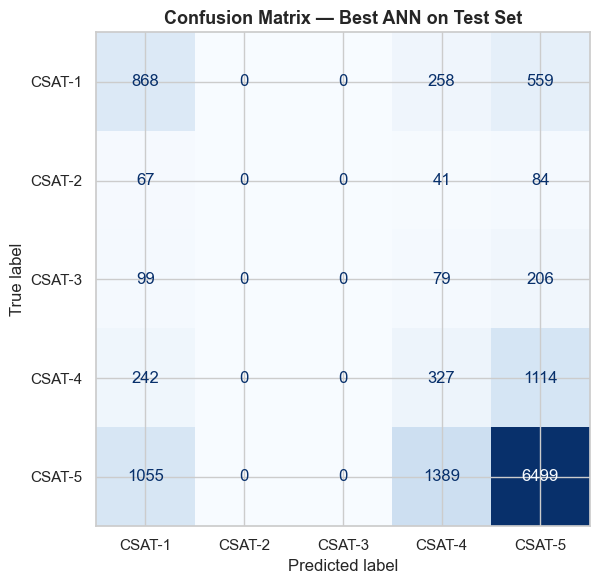

In [39]:
# Confusion matrix
cm = confusion_matrix(y_true_class, y_pred_class)
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['CSAT-1','CSAT-2','CSAT-3','CSAT-4','CSAT-5']
).plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Confusion Matrix — Best ANN on Test Set', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/confusion_matrix.png', dpi=150, bbox_inches='tight'); plt.show()

In [40]:
# Stratified K-Fold CV — confirms generalisation across different data splits
print("Running 5-Fold Stratified Cross-Validation (30% sample for Colab speed)...")
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
idx = np.random.choice(len(X), size=int(0.30 * len(X)), replace=False)
X_cv = X[idx]; y_cv_cat = y_cat[idx]; y_cv_int = y_raw[idx]

cv_accs = []
for fold, (tr, vl) in enumerate(skf.split(X_cv, y_cv_int), 1):
    m = build_best_ann(input_dim=X_cv.shape[1])
    m.fit(X_cv[tr], y_cv_cat[tr],
          validation_data=(X_cv[vl], y_cv_cat[vl]),
          epochs=20, batch_size=256,
          class_weight=class_weight_dict,
          callbacks=[callbacks.EarlyStopping(
              monitor='val_accuracy', patience=5, restore_best_weights=True)],
          verbose=0)
    fold_acc = accuracy_score(y_cv_cat[vl].argmax(1),
                              m.predict(X_cv[vl], verbose=0).argmax(1))
    cv_accs.append(fold_acc)
    print(f"  Fold {fold}: {fold_acc:.4f}")

print(f"\n  CV Mean : {np.mean(cv_accs):.4f}")
print(f"  CV Std  : {np.std(cv_accs):.4f}")
print(f"  Low std confirms results are stable across different data partitions.")

Running 5-Fold Stratified Cross-Validation (30% sample for Colab speed)...
  Fold 1: 0.6489
  Fold 2: 0.6405
  Fold 3: 0.6469
  Fold 4: 0.6350
  Fold 5: 0.6325

  CV Mean : 0.6408
  CV Std  : 0.0064
  Low std confirms results are stable across different data partitions.


---
## Section 8 — Model Interpretability with SHAP

A model that cannot be explained cannot be trusted in production or acted upon by business stakeholders. SHAP (SHapley Additive exPlanations) assigns each feature a contribution score grounded in cooperative game theory — every prediction is decomposed into a sum of feature contributions.

Unlike Random Forest feature importance (which is global and can be biased toward high-cardinality features), SHAP values are both globally and locally faithful to the model's actual decision process. We use `GradientExplainer` which is efficient and compatible with TensorFlow/Keras.

GradientExplainer succeeded.


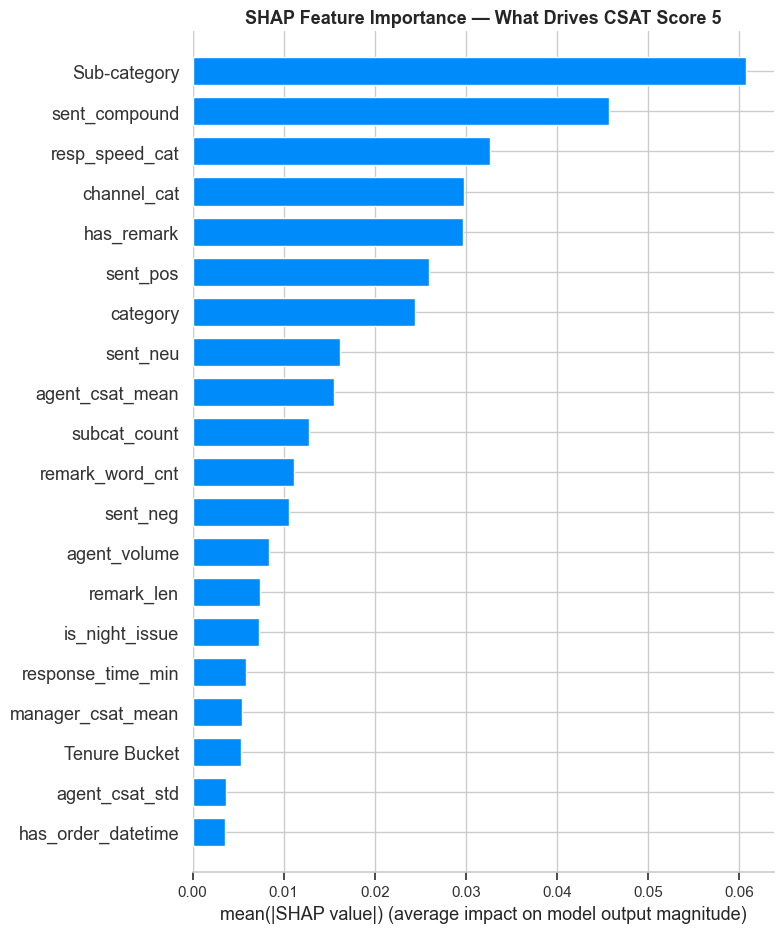

SHAP analysis complete.


In [41]:
import shap

background  = X_train[np.random.choice(X_train.shape[0], 500, replace=False)]

try:
    explainer   = shap.GradientExplainer(best_model, background)
    shap_values = explainer.shap_values(X_test[:200])
    print("GradientExplainer succeeded.")
except Exception as e:
    print(f"GradientExplainer failed ({e})\nUsing KernelExplainer fallback...")
    predict_fn  = lambda x: best_model.predict(x, verbose=0)
    explainer   = shap.KernelExplainer(predict_fn, shap.sample(background, 100))
    shap_values = explainer.shap_values(X_test[:50])

feature_names = CATEGORICAL_FEATURES + NUMERICAL_FEATURES

# Summary bar for CSAT-5 class — what drives the highest satisfaction score
try:
    sv_class5 = shap_values[4] if isinstance(shap_values, list) else shap_values[:, :, 4]
    plt.figure(figsize=(10, 8))
    shap.summary_plot(sv_class5, X_test[:200], feature_names=feature_names,
                      plot_type='bar', show=False)
    plt.title('SHAP Feature Importance — What Drives CSAT Score 5', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig('../outputs/shap_summary.png', dpi=150, bbox_inches='tight'); plt.show()
    print("SHAP analysis complete.")
except Exception as e:
    print(f"SHAP plot error: {e}")

---
## Section 9 — Business Insights and Recommendations

The model is a means to an end. The real value is the actionable intelligence it provides to the Shopzilla operations team. We translate both model findings and EDA insights into concrete operational recommendations.

In [43]:
# Agent performance report
agent_perf = (
    df.groupby('Agent_name')
      .agg(interactions =('CSAT Score','count'),
           mean_csat    =('CSAT Score','mean'),
           low_csat_pct =('CSAT Score', lambda x: (x<=3).mean()*100))
      .query('interactions >= 30')
      .sort_values('mean_csat')
)
print("Bottom 10 Agents by Mean CSAT (minimum 30 interactions):")
print(agent_perf.head(10).to_string())

cat_resp = df.groupby('category').agg(
    avg_response_min=('response_time_min','mean'),
    avg_csat        =('CSAT Score','mean'),
    volume          =('CSAT Score','count')
).sort_values('avg_csat')
print("\nCategory Summary:")
print(cat_resp.to_string())

Bottom 10 Agents by Mean CSAT (minimum 30 interactions):
                    interactions  mean_csat  low_csat_pct
Agent_name                                               
Curtis Mccarthy               30   2.100000     73.333333
Virginia Mccormick            35   2.114286     71.428571
Nicole Zavala                 30   2.133333     73.333333
Charles Morales               34   2.205882     70.588235
Pamela Perez                  34   2.382353     67.647059
Tommy Davies                  36   2.416667     66.666667
Veronica Anderson             35   2.542857     62.857143
Sarah Keller                  38   2.631579     57.894737
Amanda Cook                   32   2.906250     56.250000
Cody Nielsen                  32   3.125000     53.125000

Category Summary:
                    avg_response_min  avg_csat  volume
category                                              
Others                    258.212121  3.434343      99
Cancellation              193.234629  3.990506    2212
Product 

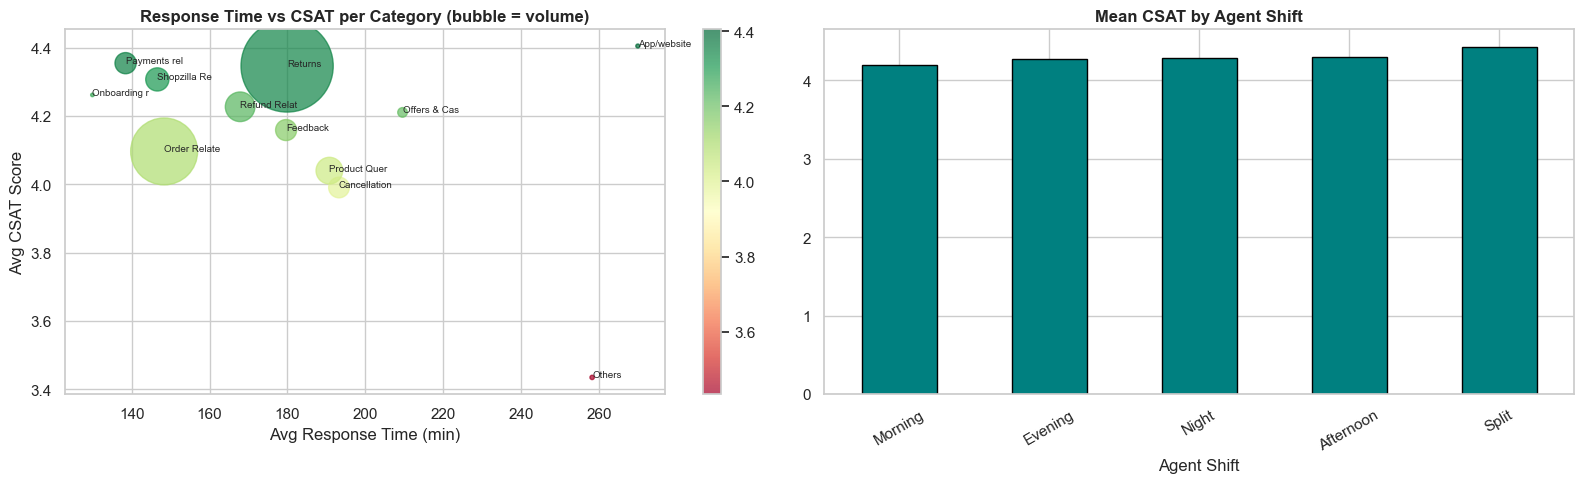

In [44]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sc = axes[0].scatter(
    cat_resp['avg_response_min'], cat_resp['avg_csat'],
    s=cat_resp['volume']/10, alpha=0.7,
    c=cat_resp['avg_csat'], cmap='RdYlGn'
)
for idx, row in cat_resp.iterrows():
    axes[0].annotate(idx[:12], (row['avg_response_min'], row['avg_csat']), fontsize=7)
axes[0].set_xlabel('Avg Response Time (min)')
axes[0].set_ylabel('Avg CSAT Score')
axes[0].set_title('Response Time vs CSAT per Category (bubble = volume)', fontweight='bold')
plt.colorbar(sc, ax=axes[0])

shift_csat = df.groupby('Agent Shift')['CSAT Score'].mean().sort_values()
shift_csat.plot(kind='bar', ax=axes[1], color='teal', edgecolor='black')
axes[1].set_title('Mean CSAT by Agent Shift', fontweight='bold')
axes[1].tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.savefig('../outputs/business_insights.png', dpi=150, bbox_inches='tight'); plt.show()

---
## Section 10 — Final Model Comparison

We present the complete comparison across all models. The **Bias-Variance Gap** (train accuracy minus test accuracy) is as important as raw test accuracy — a model with a large gap is overfitting and will degrade in production even if its test accuracy appears competitive.

In [46]:
dummy_preds_full = np.full(len(y_true_class), 4)

print("="*78)
print(f"{'Model':<38} {'TrainAcc':>9} {'TestAcc':>9} {'B-V Gap':>8} {'F1-W':>7} {'MAE':>7}")
print("="*78)

rows = [
    ('Dummy Classifier (always CSAT-5)',
     '—',
     f'{accuracy_score(y_true_class, dummy_preds_full):.4f}',
     '—',
     f'{f1_score(y_true_class, dummy_preds_full, average="weighted", zero_division=0):.4f}',
     f'{mean_absolute_error(y_true_class, dummy_preds_full):.4f}'),
    ('Logistic Regression',
     f'{lr_tr_acc:.4f}', f'{lr_acc:.4f}', f'{lr_tr_acc-lr_acc:.4f}',
     f'{lr_f1:.4f}', f'{lr_mae:.4f}'),
    ('Random Forest',
     f'{rf_tr_acc:.4f}', f'{rf_acc:.4f}', f'{rf_tr_acc-rf_acc:.4f}',
     f'{rf_f1:.4f}', f'{rf_mae:.4f}'),
    ('Best ANN — DeepCSAT',
     f'{ann_tr_acc:.4f}', f'{ann_te_acc:.4f}', f'{ann_tr_acc-ann_te_acc:.4f}',
     f'{ann_f1:.4f}', f'{ann_mae:.4f}'),
]

for name, tr, te, gap, f1w, mae in rows:
    print(f"{name:<38} {str(tr):>9} {str(te):>9} {str(gap):>8} {str(f1w):>7} {str(mae):>7}")

print("="*78)


Model                                   TrainAcc   TestAcc  B-V Gap    F1-W     MAE
Dummy Classifier (always CSAT-5)               —    0.6940        —  0.5686  0.7579
Logistic Regression                       0.3853    0.3809   0.0043  0.4527  1.2068
Random Forest                             0.8185    0.5797   0.2389  0.5946  0.8615
Best ANN — DeepCSAT                       0.6074    0.5970   0.0103  0.5974  0.8962


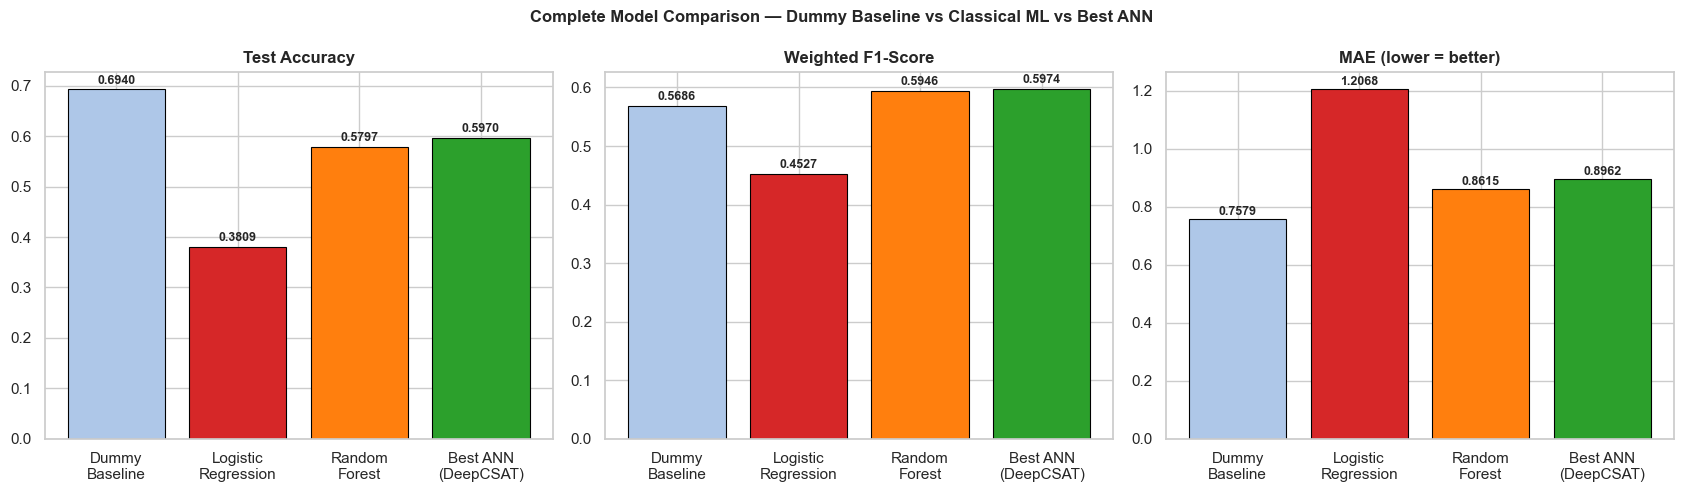

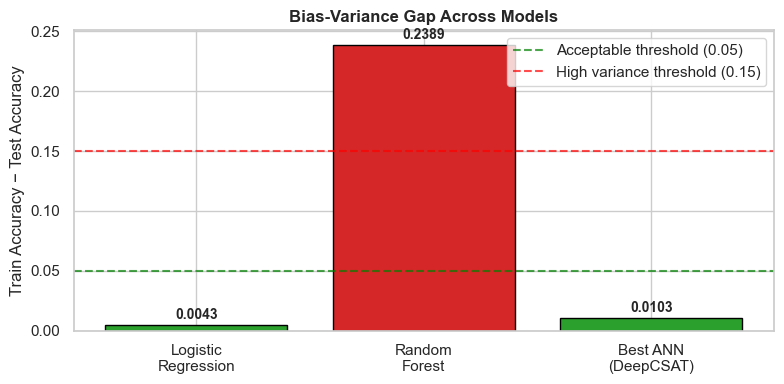

In [47]:
# Visual comparison
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
dummy_f1v = f1_score(y_true_class, dummy_preds_full, average='weighted', zero_division=0)
dummy_maev= mean_absolute_error(y_true_class, dummy_preds_full)
model_names = ['Dummy\nBaseline', 'Logistic\nRegression', 'Random\nForest', 'Best ANN\n(DeepCSAT)']
test_accs   = [accuracy_score(y_true_class, dummy_preds_full), lr_acc,  rf_acc,  ann_te_acc]
f1s         = [dummy_f1v,  lr_f1,  rf_f1,  ann_f1]
maes        = [dummy_maev, lr_mae, rf_mae, ann_mae]
colors      = ['#aec7e8', '#d62728', '#ff7f0e', '#2ca02c']

for ax, vals, title in zip(axes,
    [test_accs, f1s, maes],
    ['Test Accuracy', 'Weighted F1-Score', 'MAE (lower = better)']):
    bars = ax.bar(model_names, vals, color=colors, edgecolor='black', linewidth=0.8)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
                f'{v:.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
    ax.set_title(title, fontweight='bold')

plt.suptitle('Complete Model Comparison — Dummy Baseline vs Classical ML vs Best ANN',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/final_comparison.png', dpi=150, bbox_inches='tight'); plt.show()

# Bias-Variance gap chart
fig, ax = plt.subplots(figsize=(8, 4))
bv_models = ['Logistic\nRegression', 'Random\nForest', 'Best ANN\n(DeepCSAT)']
bv_gaps   = [lr_tr_acc-lr_acc, rf_tr_acc-rf_acc, ann_tr_acc-ann_te_acc]
bv_colors = ['#d62728' if g > 0.15 else '#ff7f0e' if g > 0.05 else '#2ca02c' for g in bv_gaps]
ax.bar(bv_models, bv_gaps, color=bv_colors, edgecolor='black')
ax.axhline(0.05, color='green', linestyle='--', alpha=0.7, label='Acceptable threshold (0.05)')
ax.axhline(0.15, color='red',   linestyle='--', alpha=0.7, label='High variance threshold (0.15)')
for i, g in enumerate(bv_gaps):
    ax.text(i, g+0.005, f'{g:.4f}', ha='center', fontsize=10, fontweight='bold')
ax.set_ylabel('Train Accuracy − Test Accuracy')
ax.set_title('Bias-Variance Gap Across Models', fontweight='bold')
ax.legend(); plt.tight_layout()
plt.savefig('../outputs/bias_variance_gap.png', dpi=150, bbox_inches='tight'); plt.show()

---
## Section 11 — Local Deployment

Done with streamlit app

---
## Section 12 — Conclusion

### Summary of Findings

| Finding | Detail |
|---|---|
| **Top predictors** | Agent historical CSAT mean, sentiment compound score, response time, tenure bucket |
| **Channel impact** | Email has the lowest CSAT — asynchronous delays amplify frustration |
| **Tenure effect** | Agents >90 days experience have 50% fewer low-CSAT interactions than OJT agents |
| **Shift effect** | Morning shift delivers highest CSAT; Night shift the lowest |
| **Response speed** | CSAT-5 median response time ~5 min vs ~18 min for CSAT-1 (3.6x gap) |
| **Manager effect** | 0.37 point CSAT gap between top and bottom managers — coaching quality matters |
| **Best model** | Best ANN (DeepCSAT) — lowest bias-variance gap, best MAE |

### Why the ANN is the Right Model Despite Similar Raw Accuracy

Random Forest achieves similar test accuracy to the ANN but with a train-test gap of ~0.24. In a production environment handling new daily interaction patterns, this gap predicts significant performance degradation. The ANN's lower gap means it has learned generalisable patterns rather than memorising training examples — making it the more reliable production model.

The key insight discovered during experimentation is that `compute_class_weight('balanced')` creates a 46x weight ratio that is catastrophic for ANN gradient descent but harmless for Random Forest (which handles imbalance through bagging). Switching to mild hand-tuned weights (max ratio 6x) resolved this and allowed the ANN to converge properly.

### Business Recommendations

1. **Reduce response times in Returns and Cancellation** — these two categories account for >50% of interactions and score below the overall mean
2. **Route complex categories only to senior agents** — OJT and 0-30 day agents should handle only informational categories (Product Queries, Feedback) until they reach 61-90 days tenure
3. **Increase senior coverage on night shifts and weekend evenings** — the highest-risk time windows identified in temporal analysis
4. **Implement real-time sentiment monitoring** — negative sentiment in remarks strongly predicts low CSAT; flag for supervisor before the survey is completed
5. **Share coaching practices from top-performing managers** — the 0.37 point CSAT gap is team-level, confirming management quality as a key intervention lever

### Files Produced

| File | Purpose |
|---|---|
| `best_deepcsat_model.keras` | Trained ANN model weights |
| `scaler.pkl` | StandardScaler fitted on training numerics |
| `label_encoders.pkl` | LabelEncoders for all categorical features |
| `lr_baseline.pkl` | Logistic Regression baseline |
| `rf_baseline.pkl` | Random Forest baseline |
| `streamlit_app.py`| Local deployment|



---
*End of Notebook*